<a href="https://colab.research.google.com/github/FLSchoolAccount/Baseball-Player-AIMODELZ/blob/main/InspiritAI1x1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from datetime import datetime
from IPython.display import display
from datetime import datetime
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Saving Teams.csv to Teams.csv
Saving Pitching.csv to Pitching.csv
Saving Fielding.csv to Fielding.csv
Saving Batting.csv to Batting.csv
Saving People.csv to People.csv
Saving Salaries.csv to Salaries.csv


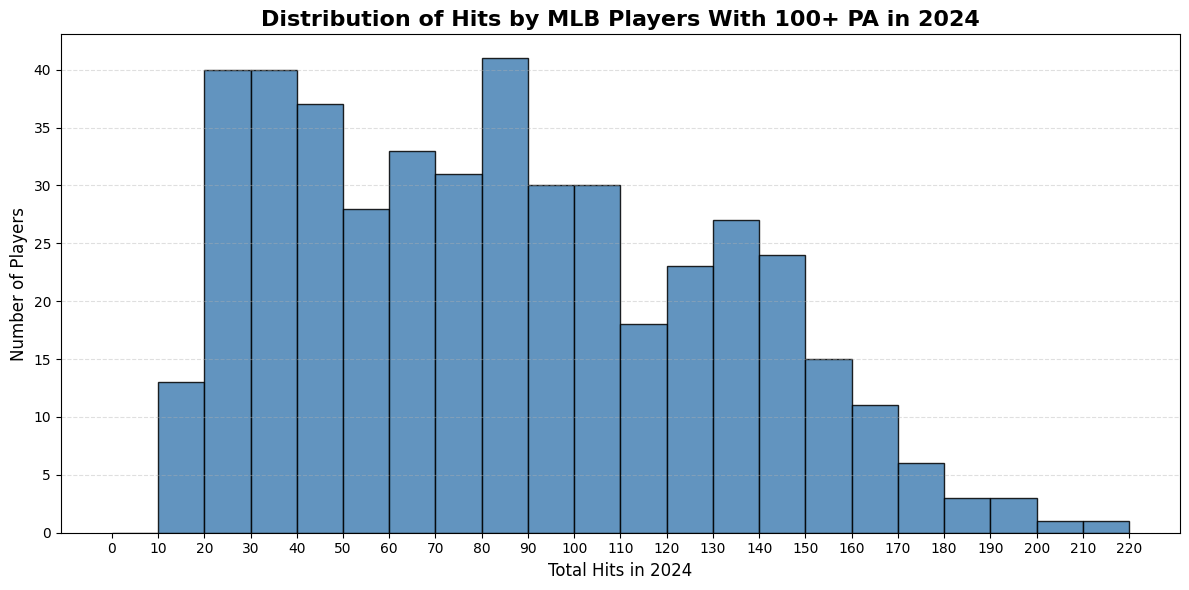

Players with at least 100 PA: 455


,playerID,Hits,At_Bats,Walks,Hit_By_Pitch,Sacrifice_Flies,Sacrifice_Hits,PA
1426,wittbo02,211,636,57,8.0,8.0,0.0,709.0
63,arraelu01,200,637,24,8.0,1.0,2.0,672.0
508,guerrvl02,199,616,72,5.0,4.0,0.0,697.0
954,ohtansh01,197,636,81,6.0,5.0,0.0,728.0
360,duranja01,191,671,54,6.0,3.0,1.0,735.0
34,altuvjo01,185,628,47,7.0,0.0,0.0,682.0
972,ozunama01,183,606,74,3.0,4.0,0.0,687.0
647,judgeaa01,180,559,133,9.0,2.0,0.0,703.0
544,hendegu01,177,630,78,7.0,4.0,0.0,719.0
1303,tovarez01,176,655,23,4.0,7.0,5.0,694.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv("Batting.csv")

# Keep 2024 rows only.
# Remove "TOT" rows to avoid double-counting players who were traded.
batting_2024 = df[
    (df["yearID"] == 2024) &
    (df["teamID"] != "TOT")
].copy()

# Combine each player's stats from every team they played for in 2024
player_stats = (
    batting_2024
    .groupby("playerID", as_index=False)
    .agg(
        Hits=("H", "sum"),
        At_Bats=("AB", "sum"),
        Walks=("BB", "sum"),
        Hit_By_Pitch=("HBP", "sum"),
        Sacrifice_Flies=("SF", "sum"),
        Sacrifice_Hits=("SH", "sum")
    )
)

# Calculate plate appearances
player_stats["PA"] = (
    player_stats["At_Bats"]
    + player_stats["Walks"]
    + player_stats["Hit_By_Pitch"]
    + player_stats["Sacrifice_Flies"]
    + player_stats["Sacrifice_Hits"]
)

# Keep only players with 100 or more plate appearances
qualified_players = player_stats[player_stats["PA"] >= 100].copy()

# Create 10-hit-wide bins: 0-9, 10-19, 20-29, etc.
bins = range(0, int(qualified_players["Hits"].max()) + 11, 10)

# Make the histogram
plt.figure(figsize=(12, 6))

plt.hist(
    qualified_players["Hits"],
    bins=bins,
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)

plt.title("Distribution of Hits by MLB Players With 100+ PA in 2024",
          fontsize=16, fontweight="bold")
plt.xlabel("Total Hits in 2024", fontsize=12)
plt.ylabel("Number of Players", fontsize=12)

plt.xticks(bins)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Optional: display the number of players included
print("Players with at least 100 PA:", len(qualified_players))

# Optional: show the leaders
qualified_players.sort_values("Hits", ascending=False).head(10)

In [ ]:
def print_missing_info(df, cols):
    """Print counts of missing values for a set of columns for quick debugging."""
    miss = df[cols].isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    if len(miss) == 0:
        print("No missing values in requested columns.")
    else:
        print("Missing values by column:")
        print(miss)

In [ ]:
# @title
def battingStats(
    year,
    batting_csv_path=None,
    fielding_csv_path=None,
    people_csv_path=None,
    verbose=False,
    batting_data=None,
    fielding_data=None,
    people_data=None
):
    if batting_data is None:
        batting = pd.read_csv(batting_csv_path)
    else:
        batting = batting_data.copy()

    if fielding_data is None:
        fielding = pd.read_csv(fielding_csv_path)
    else:
        fielding = fielding_data.copy()

    if people_data is None:
        people = pd.read_csv(people_csv_path)
    else:
        people = people_data.copy()

    batting = batting[batting["yearID"] == year].copy()
    fielding = fielding[fielding["yearID"] == year].copy()
    people = people.drop_duplicates(subset="playerID")

    if verbose:
        print(f"Number of batting records for year {year}: {len(batting)}")

    merged = batting.merge(people, on="playerID", how="left")

    merged["Name"] = (
        merged["nameFirst"].fillna("") + " " + merged["nameLast"].fillna("")
    ).str.strip()

    def safe_int(v):
        try:
            return int(v)
        except:
            return None

    def calculate_age(row):
        by = safe_int(row.get("birthYear"))
        bm = safe_int(row.get("birthMonth"))
        bd = safe_int(row.get("birthDay"))

        if by is None or bm is None or bd is None:
            return pd.NA

        try:
            birth_date = datetime(by, bm, bd)
            ref_date = datetime(year, 7, 1)

            return ref_date.year - birth_date.year - (
                (ref_date.month, ref_date.day) < (birth_date.month, birth_date.day)
            )
        except:
            return pd.NA

    merged["Age"] = merged.apply(calculate_age, axis=1)

    pos_counts = (
        fielding.groupby(["playerID", "POS"], as_index=False)["G"]
        .sum()
    )

    if pos_counts.empty:
        primary_pos = pd.DataFrame(columns=["playerID", "PrimaryPosition"])
    else:
        primary_pos = (
            pos_counts
            .sort_values(
                ["playerID", "G", "POS"],
                ascending=[True, False, True]
            )
            .drop_duplicates(subset="playerID")
            .rename(columns={"POS": "PrimaryPosition"})
            [["playerID", "PrimaryPosition"]]
        )

    fielding_stats = (
        fielding.groupby("playerID", as_index=False)[["PO", "A", "E", "DP"]]
        .sum()
    )

    def join_values(series):
        values = series.dropna().astype(str).str.strip()
        values = values[values != ""]
        return "/".join(pd.unique(values))

    batting_cols = [
        "playerID", "Name", "teamID", "Age",
        "G", "AB", "H", "BB", "HR", "2B", "3B", "SO", "HBP", "SF"
    ]

    batting_df = merged[batting_cols].copy()
    batting_df = batting_df.rename(columns={"teamID": "Team"})

    sum_cols = [
        "G", "AB", "H", "BB", "HR", "2B", "3B", "SO", "HBP", "SF"
    ]

    aggregations = {
        "Name": "first",
        "Team": join_values,
        "Age": "first"
    }

    for col in sum_cols:
        aggregations[col] = "sum"

    batting_df = batting_df.merge(primary_pos, on="playerID", how="left")
    batting_df = batting_df.merge(fielding_stats, on="playerID", how="left")

    batting_df["PrimaryPosition"] = batting_df["PrimaryPosition"].fillna("DH")

    for col in ["PO", "A", "E", "DP"]:
        batting_df[col] = pd.to_numeric(
            batting_df[col],
            errors="coerce"
        ).fillna(0)

    aggregations = {
        "Team": join_values,
        "PrimaryPosition": join_values,
        "Age": "first",
        "G": "sum",
        "AB": "sum",
        "H": "sum",
        "BB": "sum",
        "HR": "sum",
        "2B": "sum",
        "3B": "sum",
        "SO": "sum",
        "HBP": "sum",
        "SF": "sum",
        "PO": "first",
        "A": "first",
        "E": "first",
        "DP": "first"
    }

    df = (
        batting_df
        .groupby(
            ["playerID", "Name"],
            as_index=False,
            dropna=False
        )
        .agg(aggregations)
    )

    df["PrimaryPosition"] = df["PrimaryPosition"].fillna("DH")

    for col in ["PO", "A", "E", "DP"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df["G"] = pd.to_numeric(df["G"], errors="coerce").fillna(0)

    df = df[df["PrimaryPosition"] != "P"].copy()
    df = df[df["G"] > 70].reset_index(drop=True)

    for col in ["AB", "BB", "HBP", "SF", "H", "2B", "3B", "HR", "SO"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df["1B"] = df["H"] - df["2B"] - df["3B"] - df["HR"]

    df["TB"] = (
        df["1B"]
        + 2 * df["2B"]
        + 3 * df["3B"]
        + 4 * df["HR"]
    )

    ba_denom = df["AB"].replace(0, np.nan)
    obp_denom = df["AB"] + df["BB"] + df["HBP"] + df["SF"]

    df["BA"] = np.where(
        ba_denom.isna(),
        np.nan,
        df["H"] / ba_denom
    )

    df["OBP"] = np.where(
        obp_denom == 0,
        np.nan,
        (df["H"] + df["BB"] + df["HBP"]) / obp_denom
    )

    df["SLG"] = np.where(
        ba_denom.isna(),
        np.nan,
        df["TB"] / ba_denom
    )

    df["OPS"] = df["OBP"] + df["SLG"]

    fielding_denom = df["PO"] + df["A"] + df["E"]

    df["FldPct"] = np.where(
        fielding_denom == 0,
        0,
        (df["PO"] + df["A"]) / fielding_denom
    )

    for col in ["BA", "OBP", "SLG", "OPS", "FldPct"]:
        df[col] = df[col].round(3)

    df = df[
        [
            "playerID",
            "Name",
            "Team",
            "PrimaryPosition",
            "Age",
            "G",
            "AB",
            "H",
            "BB",
            "HR",
            "2B",
            "3B",
            "SO",
            "HBP",
            "SF",
            "PO",
            "A",
            "E",
            "DP",
            "FldPct",
            "1B",
            "TB",
            "BA",
            "OBP",
            "SLG",
            "OPS"
        ]
    ]

    return df

In [ ]:
# @title
from datetime import datetime
import pandas as pd

pitching = pd.read_csv("Pitching.csv")
people = pd.read_csv("People.csv")


def pitchingStats(year):
    pitch_year = pitching[pitching["yearID"] == year].copy()
    people_clean = people.drop_duplicates(subset="playerID").copy()

    merged = pitch_year.merge(
        people_clean,
        on="playerID",
        how="left",
        validate="many_to_one"
    )

    merged["Name"] = (
        merged["nameFirst"].fillna("") + " " + merged["nameLast"].fillna("")
    ).str.strip()

    def safe_int(value):
        try:
            return int(value)
        except:
            return None

    def calculate_age(row):
        birth_year = safe_int(row.get("birthYear"))
        birth_month = safe_int(row.get("birthMonth"))
        birth_day = safe_int(row.get("birthDay"))

        if birth_year is None or birth_month is None or birth_day is None:
            return pd.NA

        try:
            birth_date = datetime(birth_year, birth_month, birth_day)
            reference_date = datetime(year, 7, 1)

            return reference_date.year - birth_date.year - (
                (reference_date.month, reference_date.day)
                < (birth_date.month, birth_date.day)
            )
        except:
            return pd.NA

    merged["Age"] = merged.apply(calculate_age, axis=1)

    def join_values(series):
        values = series.dropna().astype(str).str.strip()

        values = values[
            (values != "") &
            (values.str.lower() != "nan")
        ]

        return "/".join(pd.unique(values))

    numeric_cols = [
        "W", "L", "G", "GS", "CG", "SHO", "SV",
        "IPouts", "H", "ER", "BB", "SO", "GF"
    ]

    for col in numeric_cols:
        merged[col] = pd.to_numeric(merged[col], errors="coerce").fillna(0)

    output_cols = [
        "playerID", "Name", "teamID", "Age",
        "W", "L", "G", "GS", "CG", "SHO", "SV",
        "IPouts", "H", "ER", "BB", "SO", "BAOpp", "ERA", "GF"
    ]

    pitching_df = merged[output_cols].copy()
    pitching_df = pitching_df.rename(columns={"teamID": "Team"})

    aggregations = {
        "Name": "first",
        "Team": join_values,
        "Age": "first",
        "BAOpp": join_values,
        "ERA": join_values
    }

    for col in numeric_cols:
        aggregations[col] = "sum"

    pitching_df = (
        pitching_df
        .groupby("playerID", as_index=False, dropna=False)
        .agg(aggregations)
    )

    pitching_df = pitching_df[
        (pitching_df["G"] >= 15) |
        (pitching_df["GS"] >= 10)
    ].reset_index(drop=True)

    pitching_df = pitching_df[
        [
            "Name", "Team", "Age",
            "W", "L", "G", "GS", "CG", "SHO", "SV",
            "IPouts", "H", "ER", "BB", "SO", "BAOpp", "ERA", "GF"
        ]
    ]

    pd.set_option("display.max_rows", None)

    return pitching_df


df_pitching = pitchingStats(2025)
display(df_pitching)

,Name,Team,Age,W,L,G,GS,CG,SHO,SV,IPouts,H,ER,BB,SO,BAOpp,ERA,GF


In [ ]:
# @title
from datetime import datetime
import traceback

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets

from IPython.display import clear_output, display
from sklearn.ensemble import RandomForestRegressor


# ============================================================
# LOAD DATA
# ============================================================

pitching = pd.read_csv("Pitching.csv")
people = pd.read_csv("People.csv")
salaries = pd.read_csv("Salaries.csv")

RANDOM_STATE = 42

MIN_PITCHING_YEAR = int(pitching["yearID"].min())
MAX_PITCHING_YEAR = int(pitching["yearID"].max())


# ============================================================
# PITCHER STAT TABLE
# ============================================================

def pitchingStats(year, min_games=15, min_starts=10):
    pitch_year = pitching.loc[
        pitching["yearID"] == year
    ].copy()

    if pitch_year.empty:
        return pd.DataFrame()

    people_clean = people.drop_duplicates(
        subset="playerID"
    ).copy()

    merged = pitch_year.merge(
        people_clean,
        on="playerID",
        how="left",
        validate="many_to_one"
    )

    merged["Name"] = (
        merged["nameFirst"].fillna("")
        + " "
        + merged["nameLast"].fillna("")
    ).str.strip()

    def safe_int(value):
        try:
            return int(value)
        except Exception:
            return None

    def calculate_age(row):
        birth_year = safe_int(row.get("birthYear"))
        birth_month = safe_int(row.get("birthMonth"))
        birth_day = safe_int(row.get("birthDay"))

        if (
            birth_year is None
            or birth_month is None
            or birth_day is None
        ):
            return pd.NA

        try:
            birth_date = datetime(
                birth_year,
                birth_month,
                birth_day
            )

            reference_date = datetime(
                year,
                7,
                1
            )

            return (
                reference_date.year
                - birth_date.year
                - (
                    (
                        reference_date.month,
                        reference_date.day
                    )
                    < (
                        birth_date.month,
                        birth_date.day
                    )
                )
            )

        except Exception:
            return pd.NA

    def join_values(series):
        values = series.dropna().astype(str).str.strip()

        values = values[
            (values != "")
            & (values.str.lower() != "nan")
        ]

        return "/".join(
            pd.unique(values)
        )

    merged["Age"] = merged.apply(
        calculate_age,
        axis=1
    )

    numeric_cols = [
        "W",
        "L",
        "G",
        "GS",
        "CG",
        "SHO",
        "SV",
        "IPouts",
        "H",
        "ER",
        "BB",
        "SO",
        "GF"
    ]

    for col in numeric_cols:
        merged[col] = pd.to_numeric(
            merged[col],
            errors="coerce"
        ).fillna(0)

    output_cols = [
        "playerID",
        "Name",
        "teamID",
        "Age",
        "W",
        "L",
        "G",
        "GS",
        "CG",
        "SHO",
        "SV",
        "IPouts",
        "H",
        "ER",
        "BB",
        "SO",
        "BAOpp",
        "ERA",
        "GF"
    ]

    pitching_df = merged[
        output_cols
    ].copy()

    pitching_df = pitching_df.rename(
        columns={
            "teamID": "Team"
        }
    )

    aggregations = {
        "Name": "first",
        "Team": join_values,
        "Age": "first",
        "BAOpp": join_values,
        "ERA": join_values
    }

    for col in numeric_cols:
        aggregations[col] = "sum"

    pitching_df = (
        pitching_df
        .groupby(
            "playerID",
            as_index=False,
            dropna=False
        )
        .agg(aggregations)
    )

    pitching_df = pitching_df.loc[
        (
            (pitching_df["G"] >= min_games)
            | (pitching_df["GS"] >= min_starts)
        )
    ].copy()

    pitching_df["Overall_ERA"] = np.where(
        pitching_df["IPouts"] == 0,
        np.nan,
        (
            pitching_df["ER"] * 27
        ) / pitching_df["IPouts"]
    )

    pitching_df["Overall_BAOpp"] = np.where(
        pitching_df["IPouts"] == 0,
        np.nan,
        pitching_df["H"] / (
            pitching_df["IPouts"] / 3
            + pitching_df["H"]
            + pitching_df["BB"]
        )
    )

    pitching_df["Overall_ERA"] = (
        pitching_df["Overall_ERA"]
        .round(3)
    )

    pitching_df["Overall_BAOpp"] = (
        pitching_df["Overall_BAOpp"]
        .round(3)
    )

    return pitching_df.reset_index(drop=True)


# ============================================================
# FORMULA OVR
# ============================================================

def calculate_formula_ovr(row):
    era = row["Overall_ERA"]
    ba_opp = row["Overall_BAOpp"]

    if pd.isna(era) or pd.isna(ba_opp):
        return np.nan

    if row["GS"] >= row["GF"] * 5:
        rating = (
            0.14 * (4 - era)
            + 0.0002 * row["IPouts"]
            + 0.005 * row["SO"]
            + 0.6 * (
                row["SO"] / row["IPouts"]
                if row["IPouts"] != 0
                else 0
            )
            + 0.01 * row["W"]
            + 0.1 * row["SHO"]
            - 0.00001 * row["BB"]
            - 0.1 * ba_opp
        ) * 100

    else:
        rating = (
            0.12 * (4.5 - era)
            + 0.006 * row["SO"]
            + 0.5 * (
                row["SO"] / row["IPouts"]
                if row["IPouts"] != 0
                else 0
            )
            + 0.01 * row["SV"]
            + 0.005 * row["W"]
            + 0.01 * row["GF"]
            - 0.002 * row["BB"]
            - 0.1 * ba_opp
        ) * 100

    return np.clip(
        round(rating),
        70,
        99
    )


def add_formula_ovr(df):
    df = df.copy()

    if df.empty:
        return df

    df = df.loc[
        :, ~df.columns.duplicated()
    ].copy()

    df = df.drop(
        columns=[
            "OVR",
            "Formula_OVR",
            "Predicted_OVR",
            "Potential",
            "Potential_minus_OVR"
        ],
        errors="ignore"
    )

    required_cols = [
        "Age",
        "W",
        "L",
        "G",
        "GS",
        "CG",
        "SHO",
        "SV",
        "IPouts",
        "H",
        "ER",
        "BB",
        "SO",
        "GF",
        "Overall_ERA",
        "Overall_BAOpp"
    ]

    missing = [
        col for col in required_cols
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing pitcher columns: {missing}"
        )

    df = df.dropna(
        subset=required_cols
    ).copy()

    if df.empty:
        return df

    formula_ovr_values = df.apply(
        calculate_formula_ovr,
        axis=1
    )

    df["Formula_OVR"] = (
        pd.Series(
            formula_ovr_values.to_numpy(),
            index=df.index
        )
        .clip(lower=70, upper=99)
        .round()
        .astype(int)
    )

    return df


# ============================================================
# TRAINING DATA
# ============================================================

def build_training_data(
    target_year,
    potential_window=3
):
    start_year = max(
        target_year - 10,
        MIN_PITCHING_YEAR + 1
    )

    end_year = min(
        target_year + 10,
        MAX_PITCHING_YEAR - potential_window
    )

    required_start_year = max(
        start_year - 1,
        MIN_PITCHING_YEAR
    )

    required_end_year = min(
        end_year + potential_window,
        MAX_PITCHING_YEAR
    )

    season_data = []

    for year in range(
        required_start_year,
        required_end_year + 1
    ):
        season_df = pitchingStats(year)

        if season_df.empty:
            continue

        season_df = add_formula_ovr(season_df)

        if season_df.empty:
            continue

        season_df["Season"] = year

        season_data.append(season_df)

    if not season_data:
        raise ValueError(
            "No usable pitching data exists in the required year range."
        )

    all_seasons = pd.concat(
        season_data,
        ignore_index=True
    )

    all_seasons = all_seasons.loc[
        :, ~all_seasons.columns.duplicated()
    ].copy()

    feature_cols = [
        "Age",
        "W",
        "L",
        "G",
        "GS",
        "CG",
        "SHO",
        "SV",
        "IPouts",
        "H",
        "ER",
        "BB",
        "SO",
        "GF",
        "Overall_ERA",
        "Overall_BAOpp"
    ]

    previous_season = all_seasons[
        ["playerID", "Season"] + feature_cols
    ].copy()

    previous_season["Season"] = (
        previous_season["Season"] + 1
    )

    previous_season = previous_season.rename(
        columns={
            col: f"Prev_{col}"
            for col in feature_cols
        }
    )

    current_season = all_seasons[
        [
            "playerID",
            "Season",
            "Formula_OVR"
        ]
    ].copy()

    future_ovr_parts = []

    for years_ahead in range(
        potential_window + 1
    ):
        future_part = all_seasons[
            [
                "playerID",
                "Season",
                "Formula_OVR"
            ]
        ].copy()

        future_part["Season"] = (
            future_part["Season"] - years_ahead
        )

        future_part = future_part.rename(
            columns={
                "Formula_OVR": (
                    f"Future_OVR_{years_ahead}"
                )
            }
        )

        future_ovr_parts.append(
            future_part[
                [
                    "playerID",
                    "Season",
                    f"Future_OVR_{years_ahead}"
                ]
            ]
        )

    future_ovr_df = future_ovr_parts[0]

    for future_part in future_ovr_parts[1:]:
        future_ovr_df = future_ovr_df.merge(
            future_part,
            on=[
                "playerID",
                "Season"
            ],
            how="outer",
            validate="one_to_one"
        )

    future_ovr_cols = [
        f"Future_OVR_{years_ahead}"
        for years_ahead in range(
            potential_window + 1
        )
    ]

    future_ovr_df["Potential_Target"] = (
        future_ovr_df[future_ovr_cols]
        .max(axis=1)
    )

    training_df = current_season.merge(
        previous_season,
        on=[
            "playerID",
            "Season"
        ],
        how="inner",
        validate="one_to_one"
    )

    training_df = training_df.merge(
        future_ovr_df[
            [
                "playerID",
                "Season",
                "Potential_Target"
            ]
        ],
        on=[
            "playerID",
            "Season"
        ],
        how="inner",
        validate="one_to_one"
    )

    training_df = training_df.loc[
        (
            training_df["Season"] >= start_year
        )
        & (
            training_df["Season"] <= end_year
        )
    ].copy()

    model_feature_cols = [
        f"Prev_{col}"
        for col in feature_cols
    ]

    training_df = training_df.dropna(
        subset=model_feature_cols + [
            "Formula_OVR",
            "Potential_Target"
        ]
    ).copy()

    if training_df.empty:
        raise ValueError(
            "No usable training rows were created for this year."
        )

    training_df["Formula_OVR"] = (
        training_df["Formula_OVR"]
        .clip(lower=70, upper=99)
        .round()
        .astype(int)
    )

    training_df["Potential_Target"] = (
        training_df["Potential_Target"]
        .clip(lower=70, upper=99)
        .round()
        .astype(int)
    )

    return training_df, feature_cols


# ============================================================
# SALARY MODEL
# ============================================================

def build_salary_table(
    pitching_df,
    target_year,
    salary_window=10
):
    if pitching_df.empty:
        raise ValueError(
            "No pitcher rows were supplied for salary prediction."
        )

    required_pitching_cols = [
        "playerID",
        "Name",
        "Team",
        "Age",
        "Predicted_OVR",
        "Potential",
        "W",
        "L",
        "G",
        "GS",
        "CG",
        "SHO",
        "SV",
        "IPouts",
        "H",
        "ER",
        "BB",
        "SO",
        "GF",
        "Overall_ERA",
        "Overall_BAOpp"
    ]

    missing_pitching_cols = [
        col for col in required_pitching_cols
        if col not in pitching_df.columns
    ]

    if missing_pitching_cols:
        raise ValueError(
            "Pitching salary table is missing columns: "
            f"{missing_pitching_cols}"
        )

    salaries_clean = salaries.copy()

    salaries_clean["yearID"] = pd.to_numeric(
        salaries_clean["yearID"],
        errors="coerce"
    )

    salaries_clean["salary"] = pd.to_numeric(
        salaries_clean["salary"],
        errors="coerce"
    )

    salaries_clean = salaries_clean.dropna(
        subset=[
            "playerID",
            "yearID",
            "salary"
        ]
    ).copy()

    if salaries_clean.empty:
        raise ValueError(
            "Salaries.csv contains no usable salary rows."
        )

    salaries_clean["yearID"] = (
        salaries_clean["yearID"]
        .astype(int)
    )

    salaries_clean = (
        salaries_clean
        .groupby(
            [
                "playerID",
                "yearID"
            ],
            as_index=False
        )["salary"]
        .sum()
    )

    salary_min_year = int(
        salaries_clean["yearID"].min()
    )

    salary_max_year = int(
        salaries_clean["yearID"].max()
    )

    salary_start_year = max(
        target_year - salary_window,
        salary_min_year + 1
    )

    salary_end_year = min(
        target_year + salary_window,
        salary_max_year - 1
    )

    if salary_start_year > salary_end_year:
        raise ValueError(
            f"Not enough salary history exists near {target_year}. "
            f"Salary data covers {salary_min_year}-{salary_max_year}."
        )

    salary_feature_cols = [
        "Age",
        "W",
        "L",
        "G",
        "GS",
        "CG",
        "SHO",
        "SV",
        "IPouts",
        "H",
        "ER",
        "BB",
        "SO",
        "GF",
        "Overall_ERA",
        "Overall_BAOpp"
    ]

    rating_seasons = []

    for year in range(
        salary_start_year - 1,
        salary_end_year + 1
    ):
        season_stats = pitchingStats(year)

        if season_stats.empty:
            continue

        season_stats = add_formula_ovr(
            season_stats
        ).copy()

        if season_stats.empty:
            continue

        season_stats["Season"] = year

        season_stats["Salary_Formula_OVR"] = (
            season_stats["Formula_OVR"]
            .clip(lower=70, upper=99)
            .round()
            .astype(int)
        )

        rating_seasons.append(
            season_stats[
                [
                    "playerID",
                    "Season",
                    "Age",
                    "Salary_Formula_OVR"
                ]
                + salary_feature_cols[1:]
            ].copy()
        )

    if not rating_seasons:
        raise ValueError(
            "No historical pitcher-stat rows were available "
            "for salary-model training."
        )

    historical_stats = pd.concat(
        rating_seasons,
        ignore_index=True
    )

    current_salary = salaries_clean.rename(
        columns={
            "yearID": "Season",
            "salary": "Current_Salary"
        }
    )

    next_salary = salaries_clean.copy()

    next_salary["yearID"] = (
        next_salary["yearID"] - 1
    )

    next_salary = next_salary.rename(
        columns={
            "yearID": "Season",
            "salary": "Next_Season_Salary"
        }
    )

    league_salary = (
        salaries_clean
        .groupby(
            "yearID",
            as_index=False
        )["salary"]
        .agg(
            League_Median_Salary="median",
            League_Mean_Salary="mean"
        )
        .sort_values("yearID")
        .reset_index(drop=True)
    )

    league_salary["Median_5Y_Ago"] = (
        league_salary["League_Median_Salary"]
        .shift(5)
    )

    league_salary["Inflation_5Y"] = np.where(
        league_salary["Median_5Y_Ago"] > 0,
        league_salary["League_Median_Salary"]
        / league_salary["Median_5Y_Ago"],
        1.0
    )

    league_salary["Inflation_5Y"] = (
        league_salary["Inflation_5Y"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(1.0)
    )

    league_salary = league_salary.rename(
        columns={
            "yearID": "Season"
        }
    )

    training_df = historical_stats.merge(
        current_salary,
        on=[
            "playerID",
            "Season"
        ],
        how="inner",
        validate="one_to_one"
    )

    training_df = training_df.merge(
        next_salary,
        on=[
            "playerID",
            "Season"
        ],
        how="inner",
        validate="one_to_one"
    )

    training_df = training_df.merge(
        league_salary,
        on="Season",
        how="left",
        validate="many_to_one"
    )

    training_features = [
        "Age",
        "W",
        "L",
        "G",
        "GS",
        "CG",
        "SHO",
        "SV",
        "IPouts",
        "H",
        "ER",
        "BB",
        "SO",
        "GF",
        "Overall_ERA",
        "Overall_BAOpp",
        "Salary_Formula_OVR",
        "Current_Salary",
        "League_Median_Salary",
        "League_Mean_Salary",
        "Inflation_5Y"
    ]

    training_df = training_df.dropna(
        subset=training_features + [
            "Next_Season_Salary"
        ]
    ).copy()

    if training_df.empty:
        raise ValueError(
            "No historical salary-training rows remained after "
            "matching pitcher stats to consecutive salary seasons."
        )

    training_df["Log_Next_Season_Salary"] = np.log1p(
        training_df["Next_Season_Salary"]
    )

    salary_model = RandomForestRegressor(
        n_estimators=400,
        random_state=RANDOM_STATE,
        min_samples_leaf=3,
        max_features=0.8,
        n_jobs=-1
    )

    salary_model.fit(
        training_df[training_features],
        training_df["Log_Next_Season_Salary"]
    )

    target_salaries = (
        salaries_clean.loc[
            salaries_clean["yearID"] == target_year
        ]
        .groupby(
            "playerID",
            as_index=False
        )["salary"]
        .sum()
        .rename(
            columns={
                "salary": "Salary"
            }
        )
    )

    target_league_context = league_salary.loc[
        league_salary["Season"] == target_year
    ].copy()

    if target_league_context.empty:
        target_league_context = (
            league_salary.tail(1).copy()
        )

    target_league_context = (
        target_league_context.iloc[0]
    )

    salary_output = pitching_df.copy()

    salary_output = salary_output.merge(
        target_salaries,
        on="playerID",
        how="left",
        validate="one_to_one"
    )

    salary_output["Salary"] = (
        pd.to_numeric(
            salary_output["Salary"],
            errors="coerce"
        )
        .fillna(0)
    )

    salary_output["Salary_Formula_OVR"] = (
        pd.to_numeric(
            salary_output["Predicted_OVR"],
            errors="coerce"
        )
        .fillna(70)
    )

    salary_output["Current_Salary"] = (
        salary_output["Salary"]
    )

    salary_output["League_Median_Salary"] = (
        target_league_context[
            "League_Median_Salary"
        ]
    )

    salary_output["League_Mean_Salary"] = (
        target_league_context[
            "League_Mean_Salary"
        ]
    )

    salary_output["Inflation_5Y"] = (
        target_league_context[
            "Inflation_5Y"
        ]
    )

    for col in training_features:
        if col not in salary_output.columns:
            salary_output[col] = 0

        salary_output[col] = pd.to_numeric(
            salary_output[col],
            errors="coerce"
        ).fillna(0)

    salary_output["Predicted_Salary"] = np.expm1(
        salary_model.predict(
            salary_output[training_features]
        )
    )

    salary_output["Predicted_Salary"] = (
        salary_output["Predicted_Salary"]
        .clip(lower=400000)
        .round()
        .astype("Int64")
    )

    salary_output["Salary"] = (
        salary_output["Salary"]
        .round()
        .astype("Int64")
    )

    salary_output["Salary_Difference"] = (
        salary_output["Predicted_Salary"]
        - salary_output["Salary"]
    ).astype("Int64")

    salary_output = salary_output[
        [
            "Name",
            "Team",
            "Age",
            "Predicted_OVR",
            "Potential",
            "Salary",
            "Predicted_Salary",
            "Salary_Difference"
        ]
    ].rename(
        columns={
            "Predicted_OVR": "OVR"
        }
    )

    salary_output = salary_output.sort_values(
        "Predicted_Salary",
        ascending=False
    ).reset_index(drop=True)

    return salary_output, training_df


# ============================================================
# WIDGET CONTROLS
# ============================================================

available_years = [
    year
    for year in range(
        1990,
        min(MAX_PITCHING_YEAR, 2024) + 1
    )
]

year_dropdown = widgets.Dropdown(
    options=[
        ("Select a year", None)
    ] + [
        (str(year), year)
        for year in available_years
    ],
    value=None,
    description="Year:",
    style={
        "description_width": "initial"
    },
    layout=widgets.Layout(
        width="180px"
    )
)

status = widgets.HTML(
    value=(
        "<b>Select a year to build pitcher ratings.</b>"
    )
)

loading_bar = widgets.IntProgress(
    value=0,
    min=0,
    max=4,
    description="Loading:",
    bar_style="info",
    style={
        "bar_color": "#1f77b4"
    },
    layout=widgets.Layout(
        width="400px"
    )
)

output = widgets.Output()


# ============================================================
# YEAR SELECTION EVENT
# ============================================================

def update_pitching_table(change):
    target_year = change["new"]

    if target_year is None:
        status.value = (
            "<b>Select a year to build pitcher ratings.</b>"
        )

        loading_bar.value = 0
        loading_bar.max = 4
        loading_bar.bar_style = "info"

        with output:
            clear_output(wait=True)

        return

    status.value = (
        f"<b>Loading {target_year} pitcher ratings...</b>"
    )

    loading_bar.value = 0
    loading_bar.max = 4
    loading_bar.bar_style = "info"

    with output:
        clear_output(wait=True)

        try:
            training_df, feature_cols = build_training_data(
                target_year,
                potential_window=3
            )

            model_features = [
                f"Prev_{col}"
                for col in feature_cols
            ]

            loading_bar.value = 1

            status.value = (
                f"<b>Training OVR and Potential models for "
                f"{target_year}...</b> Using "
                f"{len(training_df):,} historical pitcher-seasons."
            )

            X_train = training_df[model_features]

            y_ovr_train = training_df[
                "Formula_OVR"
            ]

            y_potential_train = training_df[
                "Potential_Target"
            ]

            ovr_model = RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                min_samples_leaf=2,
                n_jobs=-1
            )

            potential_model = RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                min_samples_leaf=2,
                n_jobs=-1
            )

            ovr_model.fit(
                X_train,
                y_ovr_train
            )

            potential_model.fit(
                X_train,
                y_potential_train
            )

            loading_bar.value = 2

            status.value = (
                f"<b>Predicting {target_year} ratings...</b>"
            )

            current_pitching = add_formula_ovr(
                pitchingStats(target_year)
            )

            previous_pitching = add_formula_ovr(
                pitchingStats(target_year - 1)
            )

            if current_pitching.empty:
                raise ValueError(
                    f"No eligible pitchers were found for {target_year}."
                )

            if previous_pitching.empty:
                raise ValueError(
                    f"No eligible pitchers were found for "
                    f"{target_year - 1}."
                )

            previous_features = previous_pitching[
                ["playerID"] + feature_cols
            ].copy()

            previous_features = previous_features.rename(
                columns={
                    col: f"Prev_{col}"
                    for col in feature_cols
                }
            )

            pitching_df = current_pitching.merge(
                previous_features,
                on="playerID",
                how="inner",
                validate="one_to_one"
            )

            pitching_df = pitching_df.dropna(
                subset=model_features
            ).copy()

            if pitching_df.empty:
                raise ValueError(
                    "No pitchers matched to previous-season features."
                )

            pitching_df["Predicted_OVR"] = (
                pd.Series(
                    ovr_model.predict(
                        pitching_df[model_features]
                    ),
                    index=pitching_df.index
                )
                .clip(lower=70, upper=99)
                .round()
                .astype(int)
            )

            pitching_df["Potential"] = (
                pd.Series(
                    potential_model.predict(
                        pitching_df[model_features]
                    ),
                    index=pitching_df.index
                )
                .clip(lower=70, upper=99)
                .round()
                .astype(int)
            )

            pitching_df["Potential"] = np.maximum(
                pitching_df["Potential"],
                pitching_df["Predicted_OVR"]
            )

            pitching_df["Potential_minus_OVR"] = (
                pitching_df["Potential"]
                - pitching_df["Predicted_OVR"]
            )

            loading_bar.value = 3

            status.value = (
                f"<b>Preparing the {target_year} pitcher table...</b>"
            )

            display_df = pitching_df[
                [
                    "Name",
                    "Team",
                    "Age",
                    "Predicted_OVR",
                    "Potential",
                    "Potential_minus_OVR",
                    "W",
                    "L",
                    "G",
                    "GS",
                    "CG",
                    "SHO",
                    "SV",
                    "IPouts",
                    "H",
                    "ER",
                    "BB",
                    "SO",
                    "BAOpp",
                    "ERA",
                    "GF"
                ]
            ].copy()

            display_df = display_df.rename(
                columns={
                    "Predicted_OVR": "OVR"
                }
            )

            display_df = display_df.sort_values(
                [
                    "OVR",
                    "Potential"
                ],
                ascending=[
                    False,
                    False
                ]
            ).reset_index(drop=True)

            print(
                f"{target_year} Pitcher Ratings"
            )

            display(display_df)

            # Salary errors no longer prevent ratings from appearing.
            try:
                salary_df, salary_training_df = (
                    build_salary_table(
                        pitching_df=pitching_df,
                        target_year=target_year,
                        salary_window=10
                    )
                )

                print(
                    f"{target_year} Pitcher Salary Estimates"
                )

                display(salary_df)

            except Exception as salary_error:
                print(
                    f"Could not build salary estimates "
                    f"for {target_year}."
                )

                print(
                    f"Salary error type: "
                    f"{type(salary_error).__name__}"
                )

                print(
                    f"Salary error message: {salary_error}"
                )

            hist_df = display_df.copy()

            hist_df["OVR"] = pd.to_numeric(
                hist_df["OVR"],
                errors="coerce"
            )

            hist_df["Potential"] = pd.to_numeric(
                hist_df["Potential"],
                errors="coerce"
            )

            hist_df = hist_df.dropna(
                subset=[
                    "OVR",
                    "Potential"
                ]
            ).copy()

            rating_bins = np.arange(
                69.5,
                100.5,
                1
            )

            fig, axes = plt.subplots(
                nrows=1,
                ncols=2,
                figsize=(16, 6),
                sharey=True
            )

            axes[0].hist(
                hist_df["OVR"].to_numpy(),
                bins=rating_bins,
                color="#1f77b4",
                edgecolor="black",
                alpha=0.8
            )

            axes[0].set_title(
                f"{target_year} Pitcher OVR Distribution"
            )

            axes[0].set_xlabel("OVR")
            axes[0].set_ylabel(
                "Number of Pitchers"
            )

            axes[0].set_xlim(69, 100)
            axes[0].set_xticks(
                range(70, 100, 5)
            )

            axes[0].grid(
                axis="y",
                alpha=0.3
            )

            axes[1].hist(
                hist_df["Potential"].to_numpy(),
                bins=rating_bins,
                color="#ff7f0e",
                edgecolor="black",
                alpha=0.8
            )

            axes[1].set_title(
                f"{target_year} Pitcher Potential Distribution"
            )

            axes[1].set_xlabel("Potential")
            axes[1].set_xlim(69, 100)

            axes[1].set_xticks(
                range(70, 100, 5)
            )

            axes[1].grid(
                axis="y",
                alpha=0.3
            )

            fig.suptitle(
                f"{target_year} Pitcher Rating Distributions",
                fontsize=16,
                fontweight="bold"
            )

            plt.tight_layout()
            plt.show()

            loading_bar.value = 4
            loading_bar.bar_style = "success"

            status.value = (
                f"<b>Finished.</b> Built "
                f"{len(display_df):,} eligible pitcher ratings "
                f"for {target_year}."
            )

        except Exception as error:
            loading_bar.value = 0
            loading_bar.bar_style = "danger"

            status.value = (
                f"<b>Could not build ratings for "
                f"{target_year}.</b>"
            )

            print(
                f"Error type: {type(error).__name__}"
            )

            print(
                f"Error message: {error}"
            )

            print("\nFull traceback:")
            traceback.print_exc()


# ============================================================
# DISPLAY DASHBOARD
# ============================================================

year_dropdown.observe(
    update_pitching_table,
    names="value"
)

display(
    year_dropdown,
    status,
    loading_bar,
    output
)

Dropdown(description='Year:', layout=Layout(width='180px'), options=(('Select a year', None), ('1990', 1990), …

HTML(value='<b>Select a year to build pitcher ratings.</b>')

IntProgress(value=0, bar_style='info', description='Loading:', layout=Layout(width='400px'), max=4, style=Prog…

Output()

In [ ]:
# @title
def build_salary_table(
    pitching_df,
    target_year,
    salary_window=10,
    max_contract_years=8
):
    if pitching_df.empty:
        raise ValueError(
            "No pitcher rows were supplied for salary prediction."
        )

    required_pitching_cols = [
        "playerID",
        "Name",
        "Team",
        "Age",
        "Predicted_OVR",
        "Potential",
        "W",
        "L",
        "G",
        "GS",
        "CG",
        "SHO",
        "SV",
        "IPouts",
        "H",
        "ER",
        "BB",
        "SO",
        "GF",
        "Overall_ERA",
        "Overall_BAOpp"
    ]

    missing_pitching_cols = [
        col for col in required_pitching_cols
        if col not in pitching_df.columns
    ]

    if missing_pitching_cols:
        raise ValueError(
            "Pitching salary table is missing columns: "
            f"{missing_pitching_cols}"
        )

    salaries_clean = salaries.copy()

    salaries_clean["yearID"] = pd.to_numeric(
        salaries_clean["yearID"],
        errors="coerce"
    )

    salaries_clean["salary"] = pd.to_numeric(
        salaries_clean["salary"],
        errors="coerce"
    )

    salaries_clean = salaries_clean.dropna(
        subset=[
            "playerID",
            "yearID",
            "salary"
        ]
    ).copy()

    if salaries_clean.empty:
        raise ValueError(
            "Salaries.csv contains no usable salary rows."
        )

    salaries_clean["yearID"] = (
        salaries_clean["yearID"]
        .astype(int)
    )

    salaries_clean = (
        salaries_clean
        .groupby(
            [
                "playerID",
                "yearID"
            ],
            as_index=False
        )["salary"]
        .sum()
    )

    salary_min_year = int(
        salaries_clean["yearID"].min()
    )

    salary_max_year = int(
        salaries_clean["yearID"].max()
    )

    salary_start_year = max(
        target_year - salary_window,
        salary_min_year + 1
    )

    salary_end_year = min(
        target_year + salary_window,
        salary_max_year - 1
    )

    if salary_start_year > salary_end_year:
        raise ValueError(
            f"Not enough salary history exists near {target_year}. "
            f"Salary data covers {salary_min_year}-{salary_max_year}."
        )

    salary_feature_cols = [
        "Age",
        "W",
        "L",
        "G",
        "GS",
        "CG",
        "SHO",
        "SV",
        "IPouts",
        "H",
        "ER",
        "BB",
        "SO",
        "GF",
        "Overall_ERA",
        "Overall_BAOpp"
    ]

    rating_seasons = []

    for year in range(
        salary_start_year - 1,
        salary_end_year + 1
    ):
        season_stats = pitchingStats(year)

        if season_stats.empty:
            continue

        season_stats = add_formula_ovr(
            season_stats
        ).copy()

        if season_stats.empty:
            continue

        season_stats["Season"] = year

        season_stats["Salary_Formula_OVR"] = (
            season_stats["Formula_OVR"]
            .clip(lower=70, upper=99)
            .round()
            .astype(int)
        )

        rating_seasons.append(
            season_stats[
                [
                    "playerID",
                    "Season",
                    "Age",
                    "Salary_Formula_OVR"
                ]
                + salary_feature_cols[1:]
            ].copy()
        )

    if not rating_seasons:
        raise ValueError(
            "No historical pitcher-stat rows were available "
            "for salary-model training."
        )

    historical_stats = pd.concat(
        rating_seasons,
        ignore_index=True
    )

    current_salary = salaries_clean.rename(
        columns={
            "yearID": "Season",
            "salary": "Current_Salary"
        }
    )

    next_salary = salaries_clean.copy()

    next_salary["yearID"] = (
        next_salary["yearID"] - 1
    )

    next_salary = next_salary.rename(
        columns={
            "yearID": "Season",
            "salary": "Next_Season_Salary"
        }
    )

    league_salary = (
        salaries_clean
        .groupby(
            "yearID",
            as_index=False
        )["salary"]
        .agg(
            League_Median_Salary="median",
            League_Mean_Salary="mean"
        )
        .sort_values("yearID")
        .reset_index(drop=True)
    )

    league_salary["Median_5Y_Ago"] = (
        league_salary["League_Median_Salary"]
        .shift(5)
    )

    league_salary["Inflation_5Y"] = np.where(
        league_salary["Median_5Y_Ago"] > 0,
        league_salary["League_Median_Salary"]
        / league_salary["Median_5Y_Ago"],
        1.0
    )

    league_salary["Inflation_5Y"] = (
        league_salary["Inflation_5Y"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(1.0)
    )

    league_salary = league_salary.rename(
        columns={
            "yearID": "Season"
        }
    )

    salary_years_by_player = (
        salaries_clean
        .groupby("playerID")["yearID"]
        .apply(
            lambda years: set(
                years.astype(int)
            )
        )
        .to_dict()
    )

    def calculate_contract_duration(
        player_id,
        season
    ):
        player_salary_years = (
            salary_years_by_player.get(
                player_id,
                set()
            )
        )

        duration = 0

        for year_ahead in range(
            1,
            max_contract_years + 1
        ):
            if (
                season + year_ahead
                in player_salary_years
            ):
                duration += 1
            else:
                break

        return duration

    training_df = historical_stats.merge(
        current_salary,
        on=[
            "playerID",
            "Season"
        ],
        how="inner",
        validate="one_to_one"
    )

    training_df = training_df.merge(
        next_salary,
        on=[
            "playerID",
            "Season"
        ],
        how="inner",
        validate="one_to_one"
    )

    training_df = training_df.merge(
        league_salary,
        on="Season",
        how="left",
        validate="many_to_one"
    )

    training_df["Contract_Duration_Target"] = (
        training_df.apply(
            lambda row: calculate_contract_duration(
                row["playerID"],
                int(row["Season"])
            ),
            axis=1
        )
    )

    training_features = [
        "Age",
        "W",
        "L",
        "G",
        "GS",
        "CG",
        "SHO",
        "SV",
        "IPouts",
        "H",
        "ER",
        "BB",
        "SO",
        "GF",
        "Overall_ERA",
        "Overall_BAOpp",
        "Salary_Formula_OVR",
        "Current_Salary",
        "League_Median_Salary",
        "League_Mean_Salary",
        "Inflation_5Y"
    ]

    training_df = training_df.dropna(
        subset=training_features + [
            "Next_Season_Salary",
            "Contract_Duration_Target"
        ]
    ).copy()

    if training_df.empty:
        raise ValueError(
            "No historical salary-training rows remained after "
            "matching pitcher stats to consecutive salary seasons."
        )

    training_df["Log_Next_Season_Salary"] = np.log1p(
        training_df["Next_Season_Salary"]
    )

    salary_model = RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        min_samples_leaf=3,
        max_features=0.8,
        n_jobs=-1
    )

    salary_model.fit(
        training_df[training_features],
        training_df["Log_Next_Season_Salary"]
    )

    duration_model = RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        min_samples_leaf=3,
        max_features=0.8,
        n_jobs=-1
    )

    duration_model.fit(
        training_df[training_features],
        training_df["Contract_Duration_Target"]
    )

    target_salaries = (
        salaries_clean.loc[
            salaries_clean["yearID"] == target_year
        ]
        .groupby(
            "playerID",
            as_index=False
        )["salary"]
        .sum()
        .rename(
            columns={
                "salary": "Salary"
            }
        )
    )

    target_league_context = league_salary.loc[
        league_salary["Season"] == target_year
    ].copy()

    if target_league_context.empty:
        target_league_context = (
            league_salary.tail(1).copy()
        )

    target_league_context = (
        target_league_context.iloc[0]
    )

    salary_output = pitching_df.copy()

    salary_output = salary_output.merge(
        target_salaries,
        on="playerID",
        how="left",
        validate="one_to_one"
    )

    salary_output["Salary"] = (
        pd.to_numeric(
            salary_output["Salary"],
            errors="coerce"
        )
        .fillna(0)
    )

    salary_output["Salary_Formula_OVR"] = (
        pd.to_numeric(
            salary_output["Predicted_OVR"],
            errors="coerce"
        )
        .fillna(70)
    )

    salary_output["Current_Salary"] = (
        salary_output["Salary"]
    )

    salary_output["League_Median_Salary"] = (
        target_league_context[
            "League_Median_Salary"
        ]
    )

    salary_output["League_Mean_Salary"] = (
        target_league_context[
            "League_Mean_Salary"
        ]
    )

    salary_output["Inflation_5Y"] = (
        target_league_context[
            "Inflation_5Y"
        ]
    )

    for col in training_features:
        if col not in salary_output.columns:
            salary_output[col] = 0

        salary_output[col] = pd.to_numeric(
            salary_output[col],
            errors="coerce"
        ).fillna(0)

    salary_output["Predicted_Salary"] = np.expm1(
        salary_model.predict(
            salary_output[training_features]
        )
    )

    salary_output["Predicted_Salary"] = (
        salary_output["Predicted_Salary"]
        .clip(lower=400000)
        .round()
        .astype("Int64")
    )

    salary_output["Projected_Contract_Years"] = (
        pd.Series(
            duration_model.predict(
                salary_output[training_features]
            ),
            index=salary_output.index
        )
        .clip(
            lower=1,
            upper=max_contract_years
        )
        .round()
        .astype(int)
    )

    salary_output["Salary"] = (
        salary_output["Salary"]
        .round()
        .astype("Int64")
    )

    salary_output["Salary_Difference"] = (
        salary_output["Predicted_Salary"]
        - salary_output["Salary"]
    ).astype("Int64")

    salary_output = salary_output[
        [
            "Name",
            "Team",
            "Age",
            "Predicted_OVR",
            "Potential",
            "Salary",
            "Predicted_Salary",
            "Projected_Contract_Years",
            "Salary_Difference"
        ]
    ].rename(
        columns={
            "Predicted_OVR": "OVR"
        }
    )

    salary_output = salary_output.sort_values(
        "Predicted_Salary",
        ascending=False
    ).reset_index(drop=True)

    return salary_output, training_df
# ============================================================
# PITCHER SALARY TABLE DROPDOWN
# ============================================================

salary_years = [
    year
    for year in range(
        max(
            1990,
            int(salaries["yearID"].min()) + 1
        ),
        int(salaries["yearID"].max())
    )
]


salary_year_dropdown = widgets.Dropdown(
    options=[
        ("Select a salary year", None)
    ] + [
        (str(year), year)
        for year in salary_years
    ],
    value=None,
    description="Salary Year:",
    style={
        "description_width": "initial"
    },
    layout=widgets.Layout(
        width="210px"
    )
)


build_salary_button = widgets.Button(
    description="Build Salary Table",
    button_style="success",
    icon="dollar",
    layout=widgets.Layout(
        width="180px"
    )
)


salary_status = widgets.HTML(
    value=(
        "<b>Select a year, then click Build Salary Table.</b>"
    )
)


salary_output = widgets.Output()


def build_pitcher_salary_year_table(button):
    target_year = salary_year_dropdown.value

    if target_year is None:
        salary_status.value = (
            "<b style='color:#b22222;'>"
            "Please select a salary year first."
            "</b>"
        )
        return

    salary_status.value = (
        f"<b>Building pitcher salary estimates and "
        f"contract-length projections for {target_year}...</b>"
    )

    build_salary_button.disabled = True

    with salary_output:
        clear_output(wait=True)

        try:
            training_df, feature_cols = build_training_data(
                target_year,
                potential_window=3
            )

            model_features = [
                f"Prev_{col}"
                for col in feature_cols
            ]

            ovr_model = RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                min_samples_leaf=2,
                n_jobs=-1
            )

            potential_model = RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                min_samples_leaf=2,
                n_jobs=-1
            )

            ovr_model.fit(
                training_df[model_features],
                training_df["Formula_OVR"]
            )

            potential_model.fit(
                training_df[model_features],
                training_df["Potential_Target"]
            )

            current_pitching = add_formula_ovr(
                pitchingStats(target_year)
            )

            previous_pitching = add_formula_ovr(
                pitchingStats(target_year - 1)
            )

            if current_pitching.empty:
                raise ValueError(
                    f"No eligible pitchers were found for "
                    f"{target_year}."
                )

            if previous_pitching.empty:
                raise ValueError(
                    f"No eligible pitchers were found for "
                    f"{target_year - 1}."
                )

            previous_features = previous_pitching[
                ["playerID"] + feature_cols
            ].rename(
                columns={
                    col: f"Prev_{col}"
                    for col in feature_cols
                }
            )

            pitcher_ratings_df = current_pitching.merge(
                previous_features,
                on="playerID",
                how="inner",
                validate="one_to_one"
            )

            pitcher_ratings_df = pitcher_ratings_df.dropna(
                subset=model_features
            ).copy()

            if pitcher_ratings_df.empty:
                raise ValueError(
                    "No pitchers could be matched to previous-season "
                    "features."
                )

            pitcher_ratings_df["Predicted_OVR"] = (
                pd.Series(
                    ovr_model.predict(
                        pitcher_ratings_df[model_features]
                    ),
                    index=pitcher_ratings_df.index
                )
                .clip(lower=70, upper=99)
                .round()
                .astype(int)
            )

            pitcher_ratings_df["Potential"] = (
                pd.Series(
                    potential_model.predict(
                        pitcher_ratings_df[model_features]
                    ),
                    index=pitcher_ratings_df.index
                )
                .clip(lower=70, upper=99)
                .round()
                .astype(int)
            )

            pitcher_ratings_df["Potential"] = np.maximum(
                pitcher_ratings_df["Potential"],
                pitcher_ratings_df["Predicted_OVR"]
            )

            salary_df, salary_training_df = build_salary_table(
                pitching_df=pitcher_ratings_df,
                target_year=target_year,
                salary_window=10,
                max_contract_years=8
            )

            print(
                f"{target_year} Pitcher Salary and "
                f"Contract-Length Estimates"
            )

            display(salary_df)

            salary_status.value = (
                f"<b style='color:#228B22;'>Finished.</b> "
                f"Built {len(salary_df):,} salary and "
                f"contract-length estimates for {target_year}."
            )

        except Exception as error:
            salary_status.value = (
                f"<b style='color:#b22222;'>Could not build "
                f"salary estimates for {target_year}.</b>"
            )

            print(
                f"Error type: {type(error).__name__}"
            )

            print(
                f"Error message: {error}"
            )

            traceback.print_exc()

        finally:
            build_salary_button.disabled = False


build_salary_button.on_click(
    build_pitcher_salary_year_table
)


salary_controls = widgets.HBox([
    salary_year_dropdown,
    build_salary_button
])


display(
    salary_controls,
    salary_status,
    salary_output
)

1996 Pitcher Salary and Contract-Length Estimates


,Name,Team,Age,OVR,Potential,Salary,Predicted_Salary,Projected_Contract_Years,Salary_Difference
0,Greg Maddux,ATL,30,97,98,6675000,6558518,7,-116482
1,John Smoltz,ATL,29,97,98,6000000,6132052,8,132052
2,Roger Clemens,BOS,33,95,97,5500000,5843216,7,343216
3,Alex Fernandez,CHA,26,97,98,4500000,5795388,6,1295388
4,Mike Mussina,BAL,27,96,98,4000000,5435505,7,1435505
5,Kevin Appier,KCA,28,96,97,5051250,4842160,7,-209090
6,Tom Glavine,ATL,30,94,96,5350000,4733465,7,-616535
7,Ramon Martinez,LAN,28,94,96,4800000,4611319,5,-188681
8,Jaime Navarro,CHN,29,94,94,3600000,4417028,5,817028
9,Andy Benes,SLN,28,96,96,3375000,4341271,6,966271


,Name,Team,Age,OVR,Potential,Potential_minus_OVR,W,L,G,GS,CG,SHO,SV,IPouts,H,ER,BB,SO,BAOpp,ERA,GF
0,Alex Fernandez,CHA,24,99,99,0,11,7,24,24,4,3,0,511,163,73,50,122,0.25,3.86,0
1,Rick Aguilera,MIN,32,98,99,1,1,4,44,0,0,0,23,134,57,18,10,46,0.306,3.63,40
2,Greg Maddux,ATL,28,98,99,1,16,6,25,25,10,3,0,606,150,35,31,156,0.207,1.56,0
3,Greg McMichael,ATL,27,98,99,1,4,6,51,0,0,0,21,176,66,25,19,47,0.28,3.84,41
4,Jeff Fassero,MON,31,98,98,0,8,6,21,21,1,0,0,416,119,46,40,119,0.229,2.99,0
5,Chuck Finley,CAL,31,98,98,0,10,10,25,25,7,2,0,550,178,88,71,148,0.26,4.32,0
6,Pedro Martinez,MON,22,98,98,0,11,5,24,23,1,1,1,434,115,55,45,142,0.22,3.42,1
7,Jose Rijo,CIN,29,98,98,0,9,6,26,26,2,0,0,517,177,59,52,171,0.265,3.08,0
8,John Wetteland,MON,27,98,98,0,4,6,52,0,0,0,25,191,46,20,21,68,0.202,2.83,43
9,Kevin Appier,KCA,26,97,99,2,7,6,23,23,1,0,0,465,137,66,63,145,0.24,3.83,0


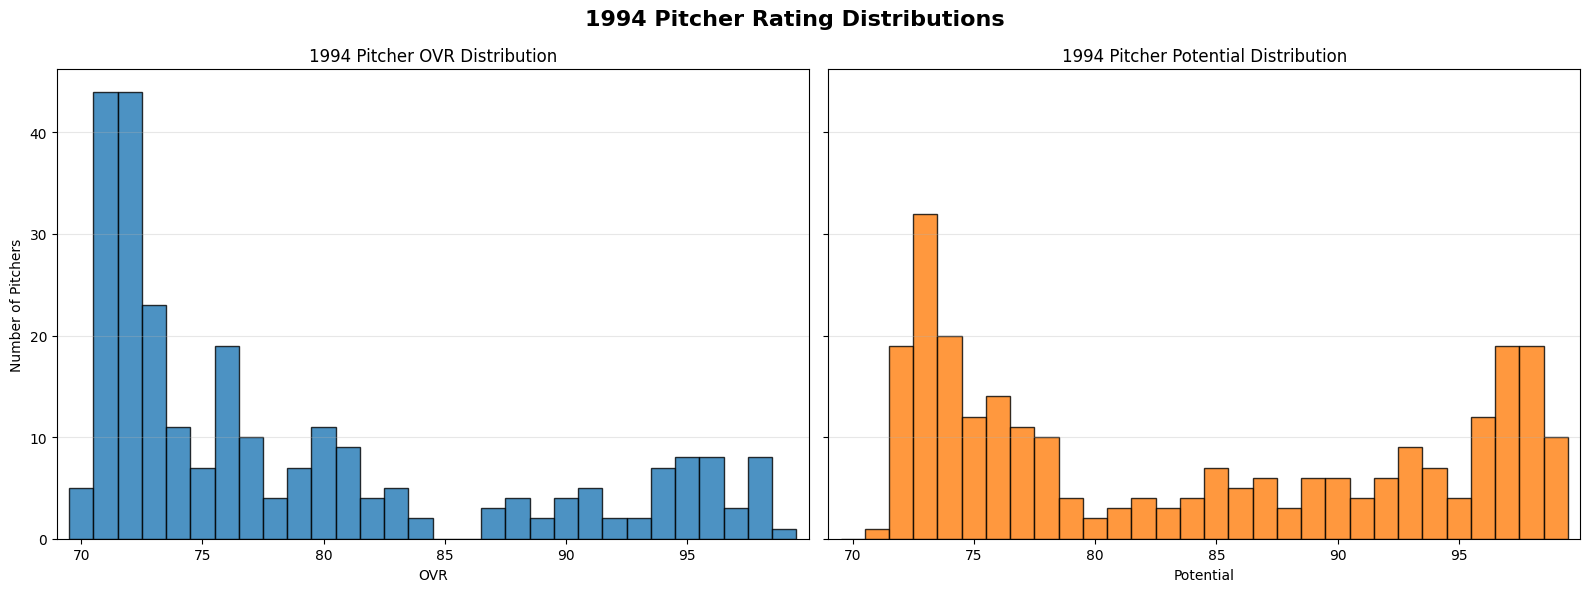

In [ ]:
# @title
import ipywidgets as widgets
from IPython.display import display, clear_output

def build_pitcher_ratings(
    target_year,
    potential_window=3,
    n_estimators=300,
    show_table=True,
    show_histograms=True
):
    training_df, feature_cols = build_training_data(
        target_year,
        potential_window=potential_window
    )

    training_df = training_df.loc[
        :, ~training_df.columns.duplicated()
    ].copy()

    model_features = [
        f"Prev_{col}"
        for col in feature_cols
    ]

    X_train = training_df[model_features]
    y_ovr_train = training_df["Formula_OVR"]
    y_potential_train = training_df["Potential_Target"]

    ovr_model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=42,
        min_samples_leaf=2,
        n_jobs=-1
    )

    potential_model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=42,
        min_samples_leaf=2,
        n_jobs=-1
    )

    ovr_model.fit(X_train, y_ovr_train)
    potential_model.fit(X_train, y_potential_train)

    current_pitching = add_formula_ovr(
        pitchingStats(target_year)
    )

    previous_pitching = add_formula_ovr(
        pitchingStats(target_year - 1)
    )

    current_pitching = current_pitching.loc[
        :, ~current_pitching.columns.duplicated()
    ].copy()

    previous_pitching = previous_pitching.loc[
        :, ~previous_pitching.columns.duplicated()
    ].copy()

    previous_features = previous_pitching[
        ["playerID"] + feature_cols
    ].copy()

    previous_features = previous_features.rename(
        columns={
            col: f"Prev_{col}"
            for col in feature_cols
        }
    )

    ratings_df = current_pitching.merge(
        previous_features,
        on="playerID",
        how="inner",
        validate="one_to_one"
    )

    ratings_df = ratings_df.loc[
        :, ~ratings_df.columns.duplicated()
    ].copy()

    ratings_df = ratings_df.drop(
        columns=[
            "OVR",
            "Predicted_OVR",
            "Potential",
            "Potential_minus_OVR"
        ],
        errors="ignore"
    )

    ratings_df = ratings_df.dropna(
        subset=model_features
    ).copy()

    ratings_df["Predicted_OVR"] = (
        pd.Series(
            ovr_model.predict(ratings_df[model_features]),
            index=ratings_df.index
        )
        .clip(lower=70, upper=99)
        .round()
        .astype(int)
    )

    ratings_df["Potential"] = (
        pd.Series(
            potential_model.predict(ratings_df[model_features]),
            index=ratings_df.index
        )
        .clip(lower=70, upper=99)
        .round()
        .astype(int)
    )

    ratings_df["Potential"] = np.maximum(
        ratings_df["Potential"],
        ratings_df["Predicted_OVR"]
    )

    ratings_df["Potential_minus_OVR"] = (
        ratings_df["Potential"]
        - ratings_df["Predicted_OVR"]
    )

    final_df = ratings_df[
        [
            "Name", "Team", "Age",
            "Predicted_OVR", "Potential", "Potential_minus_OVR",
            "W", "L", "G", "GS", "CG", "SHO", "SV",
            "IPouts", "H", "ER", "BB", "SO",
            "BAOpp", "ERA", "GF"
        ]
    ].copy()

    final_df = final_df.rename(
        columns={"Predicted_OVR": "OVR"}
    )

    final_df = final_df.loc[
        :, ~final_df.columns.duplicated()
    ].copy()

    final_df = final_df.sort_values(
        ["OVR", "Potential"],
        ascending=[False, False]
    ).reset_index(drop=True)

    if show_table:
        display(final_df)

    if show_histograms:
        hist_df = final_df.copy()

        hist_df["OVR"] = pd.to_numeric(
            hist_df["OVR"],
            errors="coerce"
        )

        hist_df["Potential"] = pd.to_numeric(
            hist_df["Potential"],
            errors="coerce"
        )

        hist_df = hist_df.dropna(
            subset=["OVR", "Potential"]
        ).copy()

        rating_bins = np.arange(69.5, 100.5, 1)

        fig, axes = plt.subplots(
            nrows=1,
            ncols=2,
            figsize=(16, 6),
            sharey=True
        )

        axes[0].hist(
            hist_df["OVR"].to_numpy(),
            bins=rating_bins,
            color="#1f77b4",
            edgecolor="black",
            alpha=0.8
        )

        axes[0].set_title(
            f"{target_year} Pitcher OVR Distribution"
        )

        axes[0].set_xlabel("OVR")
        axes[0].set_ylabel("Number of Pitchers")
        axes[0].set_xlim(69, 100)
        axes[0].set_xticks(range(70, 100, 5))
        axes[0].grid(axis="y", alpha=0.3)

        axes[1].hist(
            hist_df["Potential"].to_numpy(),
            bins=rating_bins,
            color="#ff7f0e",
            edgecolor="black",
            alpha=0.8
        )

        axes[1].set_title(
            f"{target_year} Pitcher Potential Distribution"
        )

        axes[1].set_xlabel("Potential")
        axes[1].set_xlim(69, 100)
        axes[1].set_xticks(range(70, 100, 5))
        axes[1].grid(axis="y", alpha=0.3)

        fig.suptitle(
            f"{target_year} Pitcher Rating Distributions",
            fontsize=16,
            fontweight="bold"
        )

        plt.tight_layout()
        plt.show()

    return final_df
ratings_year_dropdown = widgets.Dropdown(
    options=[("Select a year", None)] + [
        (str(year), year) for year in range(1990, 2025)
    ],
    value=None,
    description="Year:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="180px")
)

build_ratings_button = widgets.Button(
    description="Build Ratings",
    button_style="primary",
    icon="play",
    layout=widgets.Layout(width="150px")
)

ratings_status = widgets.HTML(
    value="<b>Select a year, then click Build Ratings.</b>"
)

ratings_output = widgets.Output()


def run_standalone_ratings(button):
    target_year = ratings_year_dropdown.value

    if target_year is None:
        ratings_status.value = (
            "<b style='color:#b22222;'>Please select a year first.</b>"
        )
        return

    ratings_status.value = (
        f"<b>Building OVR and Potential ratings for {target_year}...</b>"
    )

    build_ratings_button.disabled = True

    with ratings_output:
        clear_output(wait=True)

        try:
            final_df = build_pitcher_ratings(
                target_year,
                potential_window=3,
                n_estimators=300,
                show_table=True,
                show_histograms=True
            )

            ratings_status.value = (
                f"<b style='color:#228B22;'>Finished.</b> "
                f"Built {len(final_df):,} pitcher ratings for {target_year}."
            )

        except Exception as error:
            ratings_status.value = (
                f"<b style='color:#b22222;'>Could not build ratings "
                f"for {target_year}.</b>"
            )

            print(f"Error type: {type(error).__name__}")
            print(f"Error message: {error}")

        finally:
            build_ratings_button.disabled = False


build_ratings_button.on_click(run_standalone_ratings)

ratings_controls = widgets.HBox([
    ratings_year_dropdown,
    build_ratings_button
])

display(ratings_controls, ratings_status, ratings_output)

In [ ]:
print("build_pitcher_ratings" in globals())

True


In [ ]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from google.colab import data_table
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display, clear_output


# ============================================================
# SETTINGS
# ============================================================

data_table.enable_dataframe_formatter()

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

BATTING_CSV_PATH = "Batting.csv"
FIELDING_CSV_PATH = "Fielding.csv"
PEOPLE_CSV_PATH = "People.csv"

EXCLUDED_YEARS = {2020}

HITTER_STATS_CACHE = {}


# ============================================================
# DATA ACCESS
# ============================================================

def hittingStats(year):
    if year in EXCLUDED_YEARS:
        return pd.DataFrame()

    if year not in HITTER_STATS_CACHE:
        HITTER_STATS_CACHE[year] = battingStats(
            year=year,
            batting_csv_path=BATTING_CSV_PATH,
            fielding_csv_path=FIELDING_CSV_PATH,
            people_csv_path=PEOPLE_CSV_PATH,
            verbose=False
        )

    return HITTER_STATS_CACHE[year].copy()


# ============================================================
# FORMULA OVR
# ============================================================

def add_hitter_formula_ovr(df):
    df = df.copy()

    required_cols = [
        "G", "AB", "H", "BB", "HR", "2B", "3B",
        "SO", "BA", "SLG", "OBP", "OPS"
    ]

    missing = [
        col for col in required_cols
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing hitter columns needed for Formula_OVR: {missing}"
        )

    ab = pd.to_numeric(
        df["AB"],
        errors="coerce"
    ).replace(0, np.nan)

    hr = pd.to_numeric(
        df["HR"],
        errors="coerce"
    ).fillna(0)

    hits = pd.to_numeric(
        df["H"],
        errors="coerce"
    ).fillna(0)

    walks = pd.to_numeric(
        df["BB"],
        errors="coerce"
    ).fillna(0)

    strikeouts = pd.to_numeric(
        df["SO"],
        errors="coerce"
    ).fillna(0)

    ba = pd.to_numeric(
        df["BA"],
        errors="coerce"
    ).fillna(0)

    slg = pd.to_numeric(
        df["SLG"],
        errors="coerce"
    ).fillna(0)

    obp = pd.to_numeric(
        df["OBP"],
        errors="coerce"
    ).fillna(0)

    hr_per_ab = (hr / ab).fillna(0)
    sqrt_hr = np.sqrt(hr.clip(lower=0))
    sqrt_h = np.sqrt(hits.clip(lower=0))
    so_factor = strikeouts / 10

    if "E" in df.columns:
        errors = pd.to_numeric(
            df["E"],
            errors="coerce"
        ).fillna(0)

        e_component = errors - 0.95

    else:
        e_component = 0

    ovr_raw = (
        0.20 * obp
        + 0.09 * slg
        + 0.10 * hr_per_ab
        + 0.06 * sqrt_hr
        + 0.036 * sqrt_h
        + 0.00015 * walks
        - 0.0045 * so_factor
        + 0.08 * ba
        + 0.009 * e_component
    ) * 100

    df["Formula_OVR"] = (
        pd.Series(ovr_raw, index=df.index)
        .clip(lower=70, upper=99)
        .round()
        .astype(int)
    )

    return df


# ============================================================
# TRAINING DATA
# ============================================================

def build_hitter_training_data(
    target_year,
    start_year=1990,
    potential_window=3
):
    feature_cols = [
        "G", "AB", "H", "BB", "HR", "2B", "3B",
        "SO", "BA", "SLG", "OBP", "OPS"
    ]

    required_cols = [
        "playerID",
        "Name",
        "Team",
        "Age"
    ] + feature_cols

    seasons = {}

    for year in range(
        start_year - 1,
        target_year + potential_window + 1
    ):
        if year in EXCLUDED_YEARS:
            continue

        try:
            season_df = hittingStats(year)

        except Exception as error:
            print(
                f"Could not load hitter data for {year}: {error}"
            )
            continue

        if season_df is None or season_df.empty:
            continue

        season_df = season_df.loc[
            :, ~season_df.columns.duplicated()
        ].copy()

        missing = [
            col for col in required_cols
            if col not in season_df.columns
        ]

        if missing:
            print(
                f"Skipping {year}; missing columns: {missing}"
            )
            continue

        season_df = season_df.dropna(
            subset=["playerID", "Age"] + feature_cols
        ).copy()

        if season_df.empty:
            continue

        season_df = add_hitter_formula_ovr(season_df)
        season_df["Season"] = year

        ab = pd.to_numeric(
            season_df["AB"],
            errors="coerce"
        ).replace(0, np.nan)

        season_df["League_BA"] = (
            pd.to_numeric(
                season_df["BA"],
                errors="coerce"
            ).mean()
        )

        season_df["League_OBP"] = (
            pd.to_numeric(
                season_df["OBP"],
                errors="coerce"
            ).mean()
        )

        season_df["League_SLG"] = (
            pd.to_numeric(
                season_df["SLG"],
                errors="coerce"
            ).mean()
        )

        season_df["League_OPS"] = (
            pd.to_numeric(
                season_df["OPS"],
                errors="coerce"
            ).mean()
        )

        season_df["League_HR_per_AB"] = (
            pd.to_numeric(
                season_df["HR"],
                errors="coerce"
            ) / ab
        ).replace(
            [np.inf, -np.inf],
            np.nan
        ).mean()

        seasons[year] = season_df

    if len(seasons) < 3:
        raise ValueError(
            "Not enough usable seasons were loaded. "
            "Check battingStats(), playerID, and your CSV paths."
        )

    training_rows = []

    for year in range(start_year, target_year):
        previous_year = year - 1

        if year in EXCLUDED_YEARS:
            continue

        if previous_year in EXCLUDED_YEARS:
            continue

        if previous_year not in seasons:
            continue

        if year not in seasons:
            continue

        if year + 1 in EXCLUDED_YEARS:
            continue

        previous_df = seasons[previous_year].copy()
        current_df = seasons[year].copy()

        previous_features = previous_df[
            ["playerID"] + feature_cols + [
                "League_BA",
                "League_OBP",
                "League_SLG",
                "League_OPS",
                "League_HR_per_AB"
            ]
        ].copy()

        previous_features = previous_features.rename(
            columns={
                col: f"Prev_{col}"
                for col in previous_features.columns
                if col != "playerID"
            }
        )

        current_targets = current_df[
            ["playerID", "Age", "Formula_OVR"]
        ].copy()

        current_targets = current_targets.rename(
            columns={
                "Formula_OVR": "OVR_Target"
            }
        )

        current_targets["Season"] = year

        future_frames = []

        for future_year in range(
            year + 1,
            year + potential_window + 1
        ):
            if future_year in EXCLUDED_YEARS:
                continue

            if future_year not in seasons:
                continue

            future_part = seasons[future_year][
                ["playerID", "Formula_OVR"]
            ].copy()

            future_part["Future_Season"] = future_year
            future_frames.append(future_part)

        if not future_frames:
            continue

        future_df = pd.concat(
            future_frames,
            ignore_index=True
        )

        projected_ovr_target = future_df.loc[
            future_df["Future_Season"] == year + 1,
            ["playerID", "Formula_OVR"]
        ].copy()

        if projected_ovr_target.empty:
            continue

        projected_ovr_target = projected_ovr_target.rename(
            columns={
                "Formula_OVR": "Projected_OVR_Target"
            }
        )

        potential_target = (
            future_df.groupby(
                "playerID",
                as_index=False
            )["Formula_OVR"]
            .max()
            .rename(
                columns={
                    "Formula_OVR": "Potential_Target"
                }
            )
        )

        year_training = current_targets.merge(
            previous_features,
            on="playerID",
            how="inner",
            validate="one_to_one"
        )

        year_training = year_training.merge(
            projected_ovr_target,
            on="playerID",
            how="inner",
            validate="one_to_one"
        )

        year_training = year_training.merge(
            potential_target,
            on="playerID",
            how="inner",
            validate="one_to_one"
        )

        training_rows.append(year_training)

    if not training_rows:
        raise ValueError(
            "No hitter training rows were created."
        )

    training_df = pd.concat(
        training_rows,
        ignore_index=True
    )

    model_features = [
        "Age"
    ] + [
        f"Prev_{col}"
        for col in feature_cols
    ] + [
        "Prev_League_BA",
        "Prev_League_OBP",
        "Prev_League_SLG",
        "Prev_League_OPS",
        "Prev_League_HR_per_AB"
    ]

    training_df = training_df.dropna(
        subset=model_features + [
            "OVR_Target",
            "Projected_OVR_Target",
            "Potential_Target"
        ]
    ).copy()

    return training_df, feature_cols, model_features


# ============================================================
# PLAYER HISTORY
# ============================================================

def get_player_ovr_history(
    player_id,
    start_year,
    final_year
):
    history_rows = []

    for historical_year in range(
        start_year,
        final_year + 1
    ):
        if historical_year in EXCLUDED_YEARS:
            continue

        try:
            season_df = hittingStats(historical_year)

        except Exception:
            continue

        if season_df is None or season_df.empty:
            continue

        if "playerID" not in season_df.columns:
            continue

        player_season = season_df.loc[
            season_df["playerID"] == player_id
        ].copy()

        if player_season.empty:
            continue

        player_season = add_hitter_formula_ovr(
            player_season
        )

        player_season["Season"] = historical_year

        history_rows.append(
            player_season[
                [
                    "Season",
                    "Name",
                    "Team",
                    "Age",
                    "G",
                    "AB",
                    "HR",
                    "BA",
                    "OBP",
                    "SLG",
                    "OPS",
                    "Formula_OVR"
                ]
            ]
        )

    if not history_rows:
        return pd.DataFrame()

    return (
        pd.concat(
            history_rows,
            ignore_index=True
        )
        .sort_values("Season")
        .reset_index(drop=True)
    )


# ============================================================
# BUILD HITTER RATINGS
# ============================================================

def build_hitter_ratings(
    target_year,
    selected_team=None,
    start_year=1990,
    potential_window=3,
    n_estimators=300,
    show_histograms=True
):
    if target_year in EXCLUDED_YEARS:
        raise ValueError(
            f"{target_year} is excluded because it was a shortened season."
        )

    training_df, feature_cols, model_features = (
        build_hitter_training_data(
            target_year=target_year,
            start_year=start_year,
            potential_window=potential_window
        )
    )

    training_df = training_df.loc[
        training_df["Season"] < target_year
    ].copy()

    if training_df.empty:
        raise ValueError(
            f"No training data exists before {target_year}."
        )

    X_train = training_df[model_features]

    y_ovr_train = training_df["OVR_Target"]
    y_projected_ovr_train = training_df[
        "Projected_OVR_Target"
    ]
    y_potential_train = training_df[
        "Potential_Target"
    ]

    model_settings = {
        "n_estimators": n_estimators,
        "random_state": 42,
        "min_samples_leaf": 3,
        "max_features": 0.8,
        "n_jobs": -1
    }

    ovr_model = RandomForestRegressor(
        **model_settings
    )

    projected_ovr_model = RandomForestRegressor(
        **model_settings
    )

    potential_model = RandomForestRegressor(
        **model_settings
    )

    ovr_model.fit(X_train, y_ovr_train)
    projected_ovr_model.fit(
        X_train,
        y_projected_ovr_train
    )
    potential_model.fit(
        X_train,
        y_potential_train
    )

    current_hitting = hittingStats(target_year)
    previous_hitting = hittingStats(target_year - 1)

    if current_hitting.empty:
        raise ValueError(
            f"No current hitter data found for {target_year}."
        )

    if previous_hitting.empty:
        raise ValueError(
            f"No previous hitter data found for {target_year - 1}."
        )

    current_hitting = add_hitter_formula_ovr(
        current_hitting
    )

    previous_hitting = add_hitter_formula_ovr(
        previous_hitting
    )

    previous_ab = pd.to_numeric(
        previous_hitting["AB"],
        errors="coerce"
    ).replace(0, np.nan)

    previous_hitting["League_BA"] = (
        pd.to_numeric(
            previous_hitting["BA"],
            errors="coerce"
        ).mean()
    )

    previous_hitting["League_OBP"] = (
        pd.to_numeric(
            previous_hitting["OBP"],
            errors="coerce"
        ).mean()
    )

    previous_hitting["League_SLG"] = (
        pd.to_numeric(
            previous_hitting["SLG"],
            errors="coerce"
        ).mean()
    )

    previous_hitting["League_OPS"] = (
        pd.to_numeric(
            previous_hitting["OPS"],
            errors="coerce"
        ).mean()
    )

    previous_hitting["League_HR_per_AB"] = (
        pd.to_numeric(
            previous_hitting["HR"],
            errors="coerce"
        ) / previous_ab
    ).replace(
        [np.inf, -np.inf],
        np.nan
    ).mean()

    previous_features = previous_hitting[
        ["playerID"] + feature_cols + [
            "League_BA",
            "League_OBP",
            "League_SLG",
            "League_OPS",
            "League_HR_per_AB"
        ]
    ].copy()

    previous_features = previous_features.rename(
        columns={
            col: f"Prev_{col}"
            for col in previous_features.columns
            if col != "playerID"
        }
    )

    ratings_df = current_hitting.merge(
        previous_features,
        on="playerID",
        how="inner",
        validate="one_to_one"
    )

    ratings_df = ratings_df.dropna(
        subset=model_features
    ).copy()

    if ratings_df.empty:
        raise ValueError(
            "No players had matching previous-season features."
        )

    ratings_df["OVR"] = (
        pd.Series(
            ovr_model.predict(
                ratings_df[model_features]
            ),
            index=ratings_df.index
        )
        .clip(lower=70, upper=99)
        .round()
        .astype(int)
    )

    ratings_df["Projected_OVR"] = (
        pd.Series(
            projected_ovr_model.predict(
                ratings_df[model_features]
            ),
            index=ratings_df.index
        )
        .clip(lower=70, upper=99)
        .round()
        .astype(int)
    )

    ratings_df["Potential"] = (
        pd.Series(
            potential_model.predict(
                ratings_df[model_features]
            ),
            index=ratings_df.index
        )
        .clip(lower=70, upper=99)
        .round()
        .astype(int)
    )

    ratings_df["Potential"] = np.maximum(
        ratings_df["Potential"],
        ratings_df["OVR"]
    )

    final_columns = [
        "playerID",
        "Name",
        "Team",
        "PrimaryPosition",
        "Age",
        "OVR",
        "Formula_OVR",
        "Projected_OVR",
        "Potential",
        "G",
        "AB",
        "H",
        "BB",
        "HR",
        "2B",
        "SO",
        "BA",
        "SLG",
        "OBP",
        "OPS"
    ]

    final_columns = [
        col for col in final_columns
        if col in ratings_df.columns
    ]

    final_df = ratings_df[final_columns].copy()

    if selected_team is not None:
        team_mask = (
            final_df["Team"]
            .fillna("")
            .astype(str)
            .str.split("/")
            .apply(
                lambda team_list: selected_team in [
                    team.strip()
                    for team in team_list
                ]
            )
        )

        final_df = final_df.loc[
            team_mask
        ].copy()

    if final_df.empty:
        raise ValueError(
            f"No qualified hitters were found for "
            f"{selected_team} in {target_year}."
        )

    final_df = final_df.sort_values(
        by=[
            "OVR",
            "Potential",
            "Projected_OVR"
        ],
        ascending=[
            False,
            False,
            False
        ]
    ).reset_index(drop=True)

    if show_histograms:
        scatter_df = final_df.copy()

        scatter_df["OPS"] = pd.to_numeric(
            scatter_df["OPS"],
            errors="coerce"
        )

        scatter_df["OVR"] = pd.to_numeric(
            scatter_df["OVR"],
            errors="coerce"
        )

        scatter_df = scatter_df.dropna(
            subset=["OPS", "OVR"]
        ).copy()

        if not scatter_df.empty:
            plt.figure(figsize=(14, 8))

            plt.scatter(
                scatter_df["OPS"],
                scatter_df["OVR"],
                color="#1f77b4",
                edgecolor="black",
                alpha=0.70,
                s=55
            )

            plt.title(
                f"{target_year} {selected_team} Hitters: OVR vs OPS",
                fontsize=16,
                fontweight="bold"
            )

            plt.xlabel("OPS")
            plt.ylabel("OVR")
            plt.ylim(69, 100)
            plt.grid(alpha=0.30)
            plt.tight_layout()
            plt.show()

        player_options = sorted(
            [
                (
                    f"{row['Name']} ({row['Team']})",
                    row["playerID"]
                )
                for _, row in final_df.iterrows()
            ],
            key=lambda x: x[0]
        )

        player_dropdown = widgets.Dropdown(
            options=[
                ("Select a player", None)
            ] + player_options,
            value=None,
            description="Player:",
            style={
                "description_width": "initial"
            },
            layout=widgets.Layout(
                width="350px"
            )
        )

        player_graph_status = widgets.HTML(
            value=(
                "<b>Select a player to view Formula OVR history "
                "and next-season Projected OVR.</b>"
            )
        )

        player_graph_output = widgets.Output(
            layout=widgets.Layout(
                border="1px solid #cccccc",
                padding="8px"
            )
        )

        def draw_player_ovr_progression(change=None):
            selected_player_id = player_dropdown.value

            with player_graph_output:
                clear_output(wait=True)

                if selected_player_id is None:
                    print(
                        "Select a player from the dropdown "
                        "to display an OVR progression graph."
                    )
                    return

                current_player = final_df.loc[
                    final_df["playerID"] == selected_player_id
                ].copy()

                if current_player.empty:
                    print("Could not find the selected player.")
                    return

                current_player = current_player.iloc[0]

                history_df = get_player_ovr_history(
                    player_id=selected_player_id,
                    start_year=start_year,
                    final_year=target_year
                )

                if history_df.empty:
                    print(
                        f"No historical OVR data was found for "
                        f"{current_player['Name']}."
                    )
                    return

                current_formula_ovr = history_df.loc[
                    history_df["Season"] == target_year,
                    "Formula_OVR"
                ]

                if current_formula_ovr.empty:
                    current_formula_ovr = (
                        current_player["Formula_OVR"]
                    )
                else:
                    current_formula_ovr = (
                        current_formula_ovr.iloc[0]
                    )

                projected_ovr = current_player[
                    "Projected_OVR"
                ]

                plt.figure(figsize=(14, 7))

                plt.plot(
                    history_df["Season"],
                    history_df["Formula_OVR"],
                    marker="o",
                    linewidth=2.5,
                    markersize=7,
                    color="#1f77b4",
                    label="Formula OVR"
                )

                plt.plot(
                    [target_year, target_year + 1],
                    [current_formula_ovr, projected_ovr],
                    linestyle=":",
                    linewidth=3,
                    marker="o",
                    markersize=8,
                    color="#d62728",
                    label="Projected OVR"
                )

                plt.annotate(
                    f"{projected_ovr}",
                    xy=(
                        target_year + 1,
                        projected_ovr
                    ),
                    xytext=(8, 5),
                    textcoords="offset points",
                    fontsize=11,
                    fontweight="bold",
                    color="#d62728"
                )

                plt.title(
                    f"{current_player['Name']} OVR Progression",
                    fontsize=16,
                    fontweight="bold"
                )

                plt.xlabel("Season")
                plt.ylabel("OVR")
                plt.ylim(69, 100)

                plt.xticks(
                    list(history_df["Season"])
                    + [target_year + 1],
                    rotation=45
                )

                plt.grid(alpha=0.30)
                plt.legend()
                plt.tight_layout()
                plt.show()

                player_graph_status.value = (
                    f"<b style='color:#228B22;'>"
                    f"Showing {current_player['Name']}'s Formula "
                    f"OVR history through {target_year}, plus "
                    f"their {target_year + 1} Projected OVR."
                    f"</b>"
                )

        player_dropdown.observe(
            draw_player_ovr_progression,
            names="value"
        )

        display(
            player_dropdown,
            player_graph_status,
            player_graph_output
        )

    return final_df


# ============================================================
# YEAR + TEAM CONTROLS
# ============================================================

hitter_ratings_year_dropdown = widgets.Dropdown(
    options=[
        ("Select a year", None)
    ] + [
        (str(year), year)
        for year in range(1990, 2025)
        if year not in EXCLUDED_YEARS
    ],
    value=None,
    description="Year:",
    style={
        "description_width": "initial"
    },
    layout=widgets.Layout(
        width="180px"
    )
)

hitter_team_dropdown = widgets.Dropdown(
    options=[
        ("Select a team", None)
    ],
    value=None,
    description="Team:",
    disabled=True,
    style={
        "description_width": "initial"
    },
    layout=widgets.Layout(
        width="190px"
    )
)

build_hitter_ratings_button = widgets.Button(
    description="Build Hitter Ratings",
    button_style="primary",
    icon="play",
    layout=widgets.Layout(
        width="190px"
    )
)

hitter_ratings_status = widgets.HTML(
    value=(
        "<b>Select a year, then select a team.</b>"
    )
)

hitter_table_output = widgets.Output()

hitter_ratings_output = widgets.Output()


# ============================================================
# TEAM DROPDOWN UPDATE
# ============================================================

def update_hitter_team_dropdown(change):
    selected_year = change["new"]

    hitter_team_dropdown.options = [
        ("Select a team", None)
    ]

    hitter_team_dropdown.value = None
    hitter_team_dropdown.disabled = True

    if selected_year is None:
        return

    try:
        year_df = hittingStats(selected_year)

        if year_df is None or year_df.empty:
            hitter_ratings_status.value = (
                f"<b style='color:#b22222;'>"
                f"No hitter data found for {selected_year}."
                f"</b>"
            )
            return

        if "Team" not in year_df.columns:
            hitter_ratings_status.value = (
                "<b style='color:#b22222;'>"
                "The hitter data does not include a Team column."
                "</b>"
            )
            return

        team_values = (
            year_df["Team"]
            .dropna()
            .astype(str)
            .str.strip()
        )

        teams = sorted(
            team_values
            .str.split("/")
            .explode()
            .str.strip()
            .loc[
                lambda team: team != ""
            ]
            .unique()
            .tolist()
        )

        hitter_team_dropdown.options = [
            ("Select a team", None)
        ] + [
            (team, team)
            for team in teams
        ]

        hitter_team_dropdown.disabled = False

        hitter_ratings_status.value = (
            f"<b>Select a team for {selected_year}, then click "
            f"Build Hitter Ratings.</b>"
        )

    except Exception as error:
        hitter_ratings_status.value = (
            "<b style='color:#b22222;'>"
            f"Could not load teams for {selected_year}."
            "</b>"
        )

        print(
            f"Team dropdown error: "
            f"{type(error).__name__}: {error}"
        )


# ============================================================
# BUTTON EVENT
# ============================================================

def run_hitter_ratings(button):
    target_year = hitter_ratings_year_dropdown.value
    selected_team = hitter_team_dropdown.value

    if target_year is None:
        hitter_ratings_status.value = (
            "<b style='color:#b22222;'>"
            "Please select a year first."
            "</b>"
        )
        return

    if selected_team is None:
        hitter_ratings_status.value = (
            "<b style='color:#b22222;'>"
            "Please select a team first."
            "</b>"
        )
        return

    hitter_ratings_status.value = (
        f"<b>Building hitter OVR, Projected OVR, and "
        f"Potential ratings for {selected_team} in "
        f"{target_year}...</b>"
    )

    build_hitter_ratings_button.disabled = True

    with hitter_table_output:
        clear_output(wait=True)

    with hitter_ratings_output:
        clear_output(wait=True)

    try:
        with hitter_ratings_output:
            final_df = build_hitter_ratings(
                target_year=target_year,
                selected_team=selected_team,
                start_year=1990,
                potential_window=3,
                n_estimators=300,
                show_histograms=True
            )

        with hitter_table_output:
            clear_output(wait=True)
            display(final_df)

        hitter_ratings_status.value = (
            f"<b style='color:#228B22;'>Finished.</b> "
            f"Built {len(final_df):,} hitter ratings for "
            f"{selected_team} in {target_year}."
        )

    except Exception as error:
        hitter_ratings_status.value = (
            f"<b style='color:#b22222;'>Could not build "
            f"hitter ratings for {target_year}.</b>"
        )

        with hitter_ratings_output:
            print(
                f"Error type: {type(error).__name__}"
            )
            print(
                f"Error message: {error}"
            )

    finally:
        build_hitter_ratings_button.disabled = False


# ============================================================
# DISPLAY WIDGETS
# ============================================================

hitter_ratings_year_dropdown.observe(
    update_hitter_team_dropdown,
    names="value"
)

build_hitter_ratings_button.on_click(
    run_hitter_ratings
)

hitter_ratings_controls = widgets.HBox([
    hitter_ratings_year_dropdown,
    hitter_team_dropdown,
    build_hitter_ratings_button
])

display(
    hitter_ratings_controls,
    hitter_ratings_status,
    hitter_table_output,
    hitter_ratings_output
)

HTML(value='<b>Select a year, then select a team.</b>')

Output()

Output()

In [ ]:
# @title
# ============================================================
# HITTER NEXT-SEASON STAT RFR
# Uses current stats + OVR + Projected OVR + Potential
# to predict selected hitter stats for the following season.
# ============================================================

from sklearn.ensemble import RandomForestRegressor


def build_hitter_next_stat_rfr(
    start_year=1990,
    end_year=2023,
    potential_window=3,
    rating_n_estimators=300,
    stat_n_estimators=400
):
    training_rows = []

    feature_columns = [
        "Age",
        "OVR",
        "Formula_OVR",
        "Projected_OVR",
        "Potential",
        "G",
        "AB",
        "H",
        "BB",
        "HR",
        "2B",
        "SO",
        "BA",
        "OBP",
        "SLG",
        "OPS"
    ]

    target_columns = [
        "Next_H",
        "Next_HR",
        "Next_BA",
        "Next_OBP",
        "Next_SLG",
        "Next_OPS"
    ]

    for year in range(start_year, end_year):
        next_year = year + 1

        if year in EXCLUDED_YEARS:
            continue

        if next_year in EXCLUDED_YEARS:
            continue

        try:
            current_ratings = build_hitter_ratings(
                target_year=year,
                selected_team=None,
                start_year=start_year,
                potential_window=potential_window,
                n_estimators=rating_n_estimators,
                show_histograms=False
            ).copy()

            next_stats = hittingStats(next_year).copy()

        except Exception as error:
            print(
                f"Skipping {year} -> {next_year}: "
                f"{type(error).__name__}: {error}"
            )
            continue

        if current_ratings.empty or next_stats.empty:
            continue

        required_current = [
            "playerID"
        ] + feature_columns

        required_next = [
            "playerID",
            "H",
            "HR",
            "BA",
            "OBP",
            "SLG",
            "OPS"
        ]

        missing_current = [
            col for col in required_current
            if col not in current_ratings.columns
        ]

        missing_next = [
            col for col in required_next
            if col not in next_stats.columns
        ]

        if missing_current:
            print(
                f"Skipping {year}: ratings missing "
                f"{missing_current}"
            )
            continue

        if missing_next:
            print(
                f"Skipping {next_year}: batting stats missing "
                f"{missing_next}"
            )
            continue

        current_df = current_ratings[
            required_current
        ].copy()

        next_df = next_stats[
            required_next
        ].copy()

        # Your battingStats() function already aggregates player-season
        # rows by playerID. This makes the merge safe even if a player
        # changed teams during the season.
        next_df = next_df.rename(
            columns={
                "H": "Next_H",
                "HR": "Next_HR",
                "BA": "Next_BA",
                "OBP": "Next_OBP",
                "SLG": "Next_SLG",
                "OPS": "Next_OPS"
            }
        )

        training_year = current_df.merge(
            next_df,
            on="playerID",
            how="inner",
            validate="one_to_one"
        )

        if training_year.empty:
            continue

        training_year["Season"] = year

        training_rows.append(training_year)

    if not training_rows:
        raise ValueError(
            "No valid hitter seasons were available for "
            "next-season stat-model training."
        )

    stat_training_df = pd.concat(
        training_rows,
        ignore_index=True
    )

    numeric_columns = (
        feature_columns
        + target_columns
    )

    for column in numeric_columns:
        stat_training_df[column] = pd.to_numeric(
            stat_training_df[column],
            errors="coerce"
        )

    stat_training_df = stat_training_df.dropna(
        subset=numeric_columns
    ).copy()

    if stat_training_df.empty:
        raise ValueError(
            "No usable training rows remain after numeric cleaning."
        )

    stat_rfr = RandomForestRegressor(
        n_estimators=stat_n_estimators,
        random_state=42,
        min_samples_leaf=3,
        max_features=0.8,
        n_jobs=-1
    )

    stat_rfr.fit(
        stat_training_df[feature_columns],
        stat_training_df[target_columns]
    )

    return (
        stat_rfr,
        feature_columns,
        target_columns,
        stat_training_df
    )


# ============================================================
# TRAIN ONCE PER RUNTIME
# ============================================================

if "hitter_stat_rfr" not in globals():
    (
        hitter_stat_rfr,
        hitter_stat_feature_columns,
        hitter_stat_target_columns,
        hitter_stat_training_df
    ) = build_hitter_next_stat_rfr(
        start_year=1990,
        end_year=2023,
        potential_window=3,
        rating_n_estimators=300,
        stat_n_estimators=400
    )

    print(
        f"Next-season hitter stat RFR trained on "
        f"{len(hitter_stat_training_df):,} player-seasons."
    )

else:
    print(
        "Existing hitter stat RFR found. "
        "Training skipped."
    )

Skipping 1990 -> 1991: ValueError: No hitter training rows were created.
Skipping 2021 -> 2022: ValueError: No previous hitter data found for 2020.
Next-season hitter stat RFR trained on 5,847 player-seasons.


In [ ]:
# @title
# ============================================================
# RFR NEXT-SEASON HITTER STAT BACKTEST
# Predict next-year stats, then compare with actual next-year stats
# ============================================================


def predict_next_hitter_stats(
    target_year,
    selected_team,
    hitter_stat_rfr,
    hitter_stat_feature_columns,
    hitter_stat_target_columns,
    start_year=1990,
    potential_window=3,
    rating_n_estimators=300
):
    next_year = target_year + 1

    if target_year in EXCLUDED_YEARS:
        raise ValueError(
            f"{target_year} is excluded because it is a shortened season."
        )

    if next_year in EXCLUDED_YEARS:
        raise ValueError(
            f"{next_year} is excluded because it is a shortened season."
        )

    # Build hitter ratings from the selected/input season.
    # Example: Uses 2012 data to create predictions for 2013.
    ratings_df = build_hitter_ratings(
        target_year=target_year,
        selected_team=selected_team,
        start_year=start_year,
        potential_window=potential_window,
        n_estimators=rating_n_estimators,
        show_histograms=False
    ).copy()

    if ratings_df.empty:
        raise ValueError(
            f"No hitter ratings were returned for {target_year}."
        )

    prediction_df = ratings_df.copy()

    missing_features = [
        column for column in hitter_stat_feature_columns
        if column not in prediction_df.columns
    ]

    if missing_features:
        raise ValueError(
            f"Rating data is missing RFR features: {missing_features}"
        )

    for column in hitter_stat_feature_columns:
        prediction_df[column] = pd.to_numeric(
            prediction_df[column],
            errors="coerce"
        ).fillna(0)

    # Generate RFR next-season predictions.
    predicted_values = hitter_stat_rfr.predict(
        prediction_df[hitter_stat_feature_columns]
    )

    predicted_df = pd.DataFrame(
        predicted_values,
        columns=hitter_stat_target_columns,
        index=prediction_df.index
    )

    prediction_df = pd.concat(
        [
            prediction_df,
            predicted_df
        ],
        axis=1
    )

    # Clean predicted counting stats.
    for column in [
        "Next_H",
        "Next_HR"
    ]:
        prediction_df[column] = (
            pd.to_numeric(
                prediction_df[column],
                errors="coerce"
            )
            .fillna(0)
            .clip(lower=0)
            .round()
            .astype("Int64")
        )

    # Keep predicted rate stats within plausible baseball ranges.
    rate_limits = {
        "Next_BA": 0.450,
        "Next_OBP": 0.550,
        "Next_SLG": 0.850,
        "Next_OPS": 1.300
    }

    for column, upper_limit in rate_limits.items():
        prediction_df[column] = (
            pd.to_numeric(
                prediction_df[column],
                errors="coerce"
            )
            .fillna(0)
            .clip(lower=0, upper=upper_limit)
            .round(3)
        )

    # Load actual results from the following season.
    actual_df = hittingStats(next_year).copy()

    actual_columns = [
        "playerID",
        "H",
        "HR",
        "BA",
        "OBP",
        "SLG",
        "OPS"
    ]

    missing_actual_columns = [
        column for column in actual_columns
        if column not in actual_df.columns
    ]

    if missing_actual_columns:
        raise ValueError(
            f"Actual {next_year} data is missing columns: "
            f"{missing_actual_columns}"
        )

    actual_df = actual_df[
        actual_columns
    ].copy()

    # Rename actual next-year stats clearly.
    actual_df = actual_df.rename(
        columns={
            "H": f"Actual_{next_year}_H",
            "HR": f"Actual_{next_year}_HR",
            "BA": f"Actual_{next_year}_BA",
            "OBP": f"Actual_{next_year}_OBP",
            "SLG": f"Actual_{next_year}_SLG",
            "OPS": f"Actual_{next_year}_OPS"
        }
    )

    # Merge RFR predictions with real next-season results.
    comparison_df = prediction_df.merge(
        actual_df,
        on="playerID",
        how="inner",
        validate="one_to_one"
    )

    if comparison_df.empty:
        raise ValueError(
            f"No predicted {next_year} hitters matched actual "
            f"{next_year} hitter records."
        )

    # Error = predicted value minus actual result.
    error_pairs = {
        "H": (
            "Next_H",
            f"Actual_{next_year}_H"
        ),
        "HR": (
            "Next_HR",
            f"Actual_{next_year}_HR"
        ),
        "BA": (
            "Next_BA",
            f"Actual_{next_year}_BA"
        ),
        "OBP": (
            "Next_OBP",
            f"Actual_{next_year}_OBP"
        ),
        "SLG": (
            "Next_SLG",
            f"Actual_{next_year}_SLG"
        ),
        "OPS": (
            "Next_OPS",
            f"Actual_{next_year}_OPS"
        )
    }

    for stat, (predicted_column, actual_column) in error_pairs.items():
        comparison_df[f"{stat}_Prediction_Error"] = (
            pd.to_numeric(
                comparison_df[predicted_column],
                errors="coerce"
            )
            - pd.to_numeric(
                comparison_df[actual_column],
                errors="coerce"
            )
        )

        comparison_df[f"{stat}_Absolute_Error"] = (
            comparison_df[f"{stat}_Prediction_Error"]
            .abs()
        )

    # Predicted stat is placed immediately LEFT of actual next-year stat.
    display_columns = [
        "Name",
        "Team",
        "PrimaryPosition",
        "Age",
        "OVR",
        "Formula_OVR",
        "Projected_OVR",
        "Potential",

        "Next_H",
        f"Actual_{next_year}_H",
        "H_Prediction_Error",

        "Next_HR",
        f"Actual_{next_year}_HR",
        "HR_Prediction_Error",

        "Next_BA",
        f"Actual_{next_year}_BA",
        "BA_Prediction_Error",

        "Next_OBP",
        f"Actual_{next_year}_OBP",
        "OBP_Prediction_Error",

        "Next_SLG",
        f"Actual_{next_year}_SLG",
        "SLG_Prediction_Error",

        "Next_OPS",
        f"Actual_{next_year}_OPS",
        "OPS_Prediction_Error",
        "OPS_Absolute_Error"
    ]

    display_columns = [
        column for column in display_columns
        if column in comparison_df.columns
    ]

    comparison_df = comparison_df[
        display_columns
    ].copy()

    # Rename the RFR columns after selecting them.
    comparison_df = comparison_df.rename(
        columns={
            "Next_H": f"Predicted_{next_year}_H",
            "Next_HR": f"Predicted_{next_year}_HR",
            "Next_BA": f"Predicted_{next_year}_BA",
            "Next_OBP": f"Predicted_{next_year}_OBP",
            "Next_SLG": f"Predicted_{next_year}_SLG",
            "Next_OPS": f"Predicted_{next_year}_OPS"
        }
    )

    # Sort from closest OPS projection to largest OPS miss.
    comparison_df = comparison_df.sort_values(
        by="OPS_Absolute_Error",
        ascending=True
    ).reset_index(drop=True)

    return comparison_df
    # Round both predicted and actual rate stats to three decimals.
    rate_display_columns = [
        f"Predicted_{next_year}_BA",
        f"Actual_{next_year}_BA",
        f"Predicted_{next_year}_OBP",
        f"Actual_{next_year}_OBP",
        f"Predicted_{next_year}_SLG",
        f"Actual_{next_year}_SLG",
        f"Predicted_{next_year}_OPS",
        f"Actual_{next_year}_OPS"
    ]

    for column in rate_display_columns:
        if column in comparison_df.columns:
            comparison_df[column] = pd.to_numeric(
                comparison_df[column],
                errors="coerce"
            ).round(3)



In [ ]:
# ============================================================
# RFR PREDICTION / ACTUAL COMPARISON DROPDOWNS
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output


# Blank starting option = None.
rfr_prediction_year_dropdown = widgets.Dropdown(
    options=[
        ("", None)
    ] + [
        (str(year), year)
        for year in range(1991, 2024)
        if year not in EXCLUDED_YEARS
        and year + 1 not in EXCLUDED_YEARS
    ],
    value=None,
    description="Prediction year:",
    style={
        "description_width": "initial"
    },
    layout=widgets.Layout(
        width="220px"
    )
)


# Starts blank and disabled until a year is selected.
rfr_prediction_team_dropdown = widgets.Dropdown(
    options=[
        ("", None)
    ],
    value=None,
    description="Team:",
    disabled=True,
    style={
        "description_width": "initial"
    },
    layout=widgets.Layout(
        width="180px"
    )
)


rfr_prediction_button = widgets.Button(
    description="Run RFR Comparison",
    button_style="primary",
    icon="play",
    layout=widgets.Layout(
        width="200px"
    )
)


rfr_prediction_status = widgets.HTML(
    value=(
        "<b>Select a prediction year, then select a team.</b>"
    )
)


rfr_prediction_output = widgets.Output()


# ============================================================
# UPDATE TEAM DROPDOWN WHEN YEAR CHANGES
# ============================================================

def update_rfr_prediction_team_dropdown(change):
    selected_year = change["new"]

    rfr_prediction_team_dropdown.options = [
        ("", None)
    ]

    rfr_prediction_team_dropdown.value = None
    rfr_prediction_team_dropdown.disabled = True

    if selected_year is None:
        rfr_prediction_status.value = (
            "<b>Select a prediction year.</b>"
        )
        return

    try:
        year_df = hittingStats(selected_year)

        if year_df is None or year_df.empty:
            rfr_prediction_status.value = (
                f"<b style='color:#b22222;'>"
                f"No hitter data found for {selected_year}."
                f"</b>"
            )
            return

        if "Team" not in year_df.columns:
            rfr_prediction_status.value = (
                "<b style='color:#b22222;'>"
                "The hitter data does not have a Team column."
                "</b>"
            )
            return

        team_values = (
            year_df["Team"]
            .dropna()
            .astype(str)
            .str.strip()
        )

        teams = sorted(
            team_values
            .str.split("/")
            .explode()
            .str.strip()
            .loc[
                lambda team: team != ""
            ]
            .unique()
            .tolist()
        )

        rfr_prediction_team_dropdown.options = [
            ("", None)
        ] + [
            (team, team)
            for team in teams
        ]

        rfr_prediction_team_dropdown.disabled = False

        rfr_prediction_status.value = (
            f"<b>Select a team for {selected_year}, then click "
            f"Run RFR Comparison.</b>"
        )

    except Exception as error:
        rfr_prediction_status.value = (
            f"<b style='color:#b22222;'>"
            f"Could not load teams for {selected_year}."
            f"</b>"
        )

        print(
            f"RFR team dropdown error: "
            f"{type(error).__name__}: {error}"
        )


# ============================================================
# RUN RFR COMPARISON BUTTON
# ============================================================

def run_rfr_prediction_comparison(button):
    prediction_year = rfr_prediction_year_dropdown.value
    prediction_team = rfr_prediction_team_dropdown.value

    if prediction_year is None:
        rfr_prediction_status.value = (
            "<b style='color:#b22222;'>"
            "Please select a prediction year."
            "</b>"
        )
        return

    if prediction_team is None:
        rfr_prediction_status.value = (
            "<b style='color:#b22222;'>"
            "Please select a team."
            "</b>"
        )
        return

    required_rfr_objects = [
        "hitter_stat_rfr",
        "hitter_stat_feature_columns",
        "hitter_stat_target_columns"
    ]

    missing_rfr_objects = [
        variable
        for variable in required_rfr_objects
        if variable not in globals()
    ]

    if missing_rfr_objects:
        rfr_prediction_status.value = (
            "<b style='color:#b22222;'>"
            "The RFR stat model has not been trained yet."
            "</b>"
        )

        with rfr_prediction_output:
            clear_output(wait=True)

            print(
                "Run your one-time RFR training cell first."
            )

            print(
                "Missing objects:",
                missing_rfr_objects
            )

        return

    rfr_prediction_button.disabled = True

    rfr_prediction_status.value = (
        f"<b>Using {prediction_year} {prediction_team} inputs "
        f"to predict and compare actual "
        f"{prediction_year + 1} statistics...</b>"
    )

    try:
        with rfr_prediction_output:
            clear_output(wait=True)

            comparison_table = predict_next_hitter_stats(
                target_year=prediction_year,
                selected_team=prediction_team,
                hitter_stat_rfr=hitter_stat_rfr,
                hitter_stat_feature_columns=(
                    hitter_stat_feature_columns
                ),
                hitter_stat_target_columns=(
                    hitter_stat_target_columns
                ),
                start_year=1990,
                potential_window=3,
                rating_n_estimators=300
            )

            print(
                f"RFR Predicted {prediction_year + 1} Stats "
                f"vs Actual {prediction_year + 1} Stats: "
                f"{prediction_team}"
            )

            print(
                f"Matched hitters displayed: "
                f"{len(comparison_table):,}"
            )

            display(comparison_table)

        rfr_prediction_status.value = (
            f"<b style='color:#228B22;'>Finished.</b> "
            f"Displayed predicted vs. actual "
            f"{prediction_year + 1} statistics for "
            f"{prediction_team}."
        )

    except Exception as error:
        rfr_prediction_status.value = (
            f"<b style='color:#b22222;'>"
            f"Could not build the RFR comparison table."
            f"</b>"
        )

        with rfr_prediction_output:
            clear_output(wait=True)

            print(
                f"Error type: {type(error).__name__}"
            )

            print(
                f"Error message: {error}"
            )

    finally:
        rfr_prediction_button.disabled = False


# ============================================================
# DISPLAY RFR PREDICTION CONTROLS
# ============================================================

rfr_prediction_year_dropdown.observe(
    update_rfr_prediction_team_dropdown,
    names="value"
)

rfr_prediction_button.on_click(
    run_rfr_prediction_comparison
)

rfr_prediction_controls = widgets.HBox([
    rfr_prediction_year_dropdown,
    rfr_prediction_team_dropdown,
    rfr_prediction_button
])

display(
    rfr_prediction_controls,
    rfr_prediction_status,
    rfr_prediction_output
)

HTML(value='<b>Select a prediction year, then select a team.</b>')

Output()

In [ ]:
# ============================================================
# LEAGUE-WIDE RFR DEVIATION TRENDS
# Uses current trained RFR to predict next-year league hitters
# and compares projections to actual following-season outcomes.
# ============================================================

def build_league_rfr_deviation_trends(
    start_year=1991,
    end_year=2020,
    hitter_stat_rfr=None,
    hitter_stat_feature_columns=None,
    hitter_stat_target_columns=None,
    model_start_year=1990,
    potential_window=3,
    rating_n_estimators=300
):
    if hitter_stat_rfr is None:
        raise ValueError(
            "hitter_stat_rfr is required. "
            "Run the one-time RFR training cell first."
        )

    yearly_rows = []

    stat_error_columns = [
        "H_Prediction_Error",
        "HR_Prediction_Error",
        "BA_Prediction_Error",
        "OBP_Prediction_Error",
        "SLG_Prediction_Error",
        "OPS_Prediction_Error"
    ]

    for year in range(start_year, end_year + 1):
        next_year = year + 1

        if year in EXCLUDED_YEARS:
            continue

        if next_year in EXCLUDED_YEARS:
            continue

        try:
            # selected_team=None creates a league-wide table.
            year_comparison = predict_next_hitter_stats(
                target_year=year,
                selected_team=None,
                hitter_stat_rfr=hitter_stat_rfr,
                hitter_stat_feature_columns=(
                    hitter_stat_feature_columns
                ),
                hitter_stat_target_columns=(
                    hitter_stat_target_columns
                ),
                start_year=model_start_year,
                potential_window=potential_window,
                rating_n_estimators=rating_n_estimators
            ).copy()

        except Exception as error:
            print(
                f"Skipping {year} -> {next_year}: "
                f"{type(error).__name__}: {error}"
            )
            continue

        if year_comparison.empty:
            print(
                f"Skipping {year} -> {next_year}: "
                "No matched hitter rows."
            )
            continue

        trend_row = {
            "Prediction_Year": year,
            "Actual_Year": next_year,
            "Matched_Hitters": len(year_comparison)
        }

        for column in stat_error_columns:
            if column in year_comparison.columns:
                values = pd.to_numeric(
                    year_comparison[column],
                    errors="coerce"
                )

                stat_name = column.replace(
                    "_Prediction_Error",
                    ""
                )

                # Signed error:
                # Positive = RFR projected too high on average.
                # Negative = RFR projected too low on average.
                trend_row[f"{stat_name}_Mean_Error"] = (
                    values.mean()
                )

                # Absolute error:
                # Average size of the miss, ignoring direction.
                trend_row[f"{stat_name}_MAE"] = (
                    values.abs().mean()
                )

        yearly_rows.append(trend_row)

        print(
            f"Completed {year} -> {next_year}: "
            f"{len(year_comparison):,} matched hitters"
        )

    if not yearly_rows:
        raise ValueError(
            "No league-wide RFR comparison rows were created."
        )

    trend_df = pd.DataFrame(yearly_rows)

    return trend_df.sort_values(
        "Prediction_Year"
    ).reset_index(drop=True)

In [ ]:
league_rfr_trends = build_league_rfr_deviation_trends(
    start_year=1991,
    end_year=2020,
    hitter_stat_rfr=hitter_stat_rfr,
    hitter_stat_feature_columns=hitter_stat_feature_columns,
    hitter_stat_target_columns=hitter_stat_target_columns,
    model_start_year=1990,
    potential_window=3,
    rating_n_estimators=300
)

display(league_rfr_trends)

Completed 1991 -> 1992: 194 matched hitters
Completed 1992 -> 1993: 200 matched hitters
Completed 1993 -> 1994: 171 matched hitters
Completed 1994 -> 1995: 178 matched hitters
Completed 1995 -> 1996: 175 matched hitters
Completed 1996 -> 1997: 205 matched hitters
Completed 1997 -> 1998: 214 matched hitters
Completed 1998 -> 1999: 216 matched hitters
Completed 1999 -> 2000: 222 matched hitters
Completed 2000 -> 2001: 218 matched hitters
Completed 2001 -> 2002: 216 matched hitters
Completed 2002 -> 2003: 209 matched hitters
Completed 2003 -> 2004: 210 matched hitters
Completed 2004 -> 2005: 215 matched hitters
Completed 2005 -> 2006: 210 matched hitters
Completed 2006 -> 2007: 208 matched hitters
Completed 2007 -> 2008: 208 matched hitters
Completed 2008 -> 2009: 211 matched hitters
Completed 2009 -> 2010: 214 matched hitters
Completed 2010 -> 2011: 205 matched hitters
Completed 2011 -> 2012: 195 matched hitters
Completed 2012 -> 2013: 189 matched hitters
Completed 2013 -> 2014: 201 matc

,Prediction_Year,Actual_Year,Matched_Hitters,H_Mean_Error,H_MAE,HR_Mean_Error,HR_MAE,BA_Mean_Error,BA_MAE,OBP_Mean_Error,OBP_MAE,SLG_Mean_Error,SLG_MAE,OPS_Mean_Error,OPS_MAE
0,1991,1992,194,-0.773196,12.340206,1.572165,3.386598,0.002541,0.015696,0.001897,0.020598,0.017268,0.032433,0.019206,0.046423
1,1992,1993,200,-2.165000,13.835000,-0.710000,3.700000,-0.004950,0.018710,-0.006375,0.022785,-0.009205,0.039185,-0.015550,0.056000
2,1993,1994,171,11.672515,13.730994,0.672515,3.187135,-0.010836,0.019047,-0.012579,0.023760,-0.025175,0.040637,-0.037766,0.056901
3,1994,1995,178,-1.084270,12.084270,0.258427,3.696629,-0.006185,0.018039,-0.008275,0.020691,-0.006972,0.037208,-0.015281,0.051674
4,1995,1996,175,-8.708571,15.348571,-2.102857,4.708571,-0.005217,0.015674,-0.007783,0.020926,-0.012137,0.037189,-0.019943,0.052537
5,1996,1997,205,1.282927,12.356098,0.721951,3.687805,-0.001434,0.014927,-0.001376,0.021493,0.003063,0.033229,0.001737,0.048537
6,1997,1998,214,-1.691589,14.560748,0.219626,4.191589,-0.002332,0.016360,-0.002864,0.020603,0.001453,0.035481,-0.001486,0.048383
7,1998,1999,216,-1.148148,14.305556,-0.689815,4.254630,-0.007542,0.018060,-0.012741,0.023130,-0.013824,0.038796,-0.026579,0.054551
8,1999,2000,222,0.387387,14.216216,-0.378378,3.864865,-0.002923,0.017086,-0.006477,0.021919,-0.009680,0.039374,-0.016176,0.055635
9,2000,2001,218,1.967890,12.334862,0.408257,4.298165,0.001436,0.015739,0.003904,0.018784,0.002096,0.035986,0.005972,0.049239


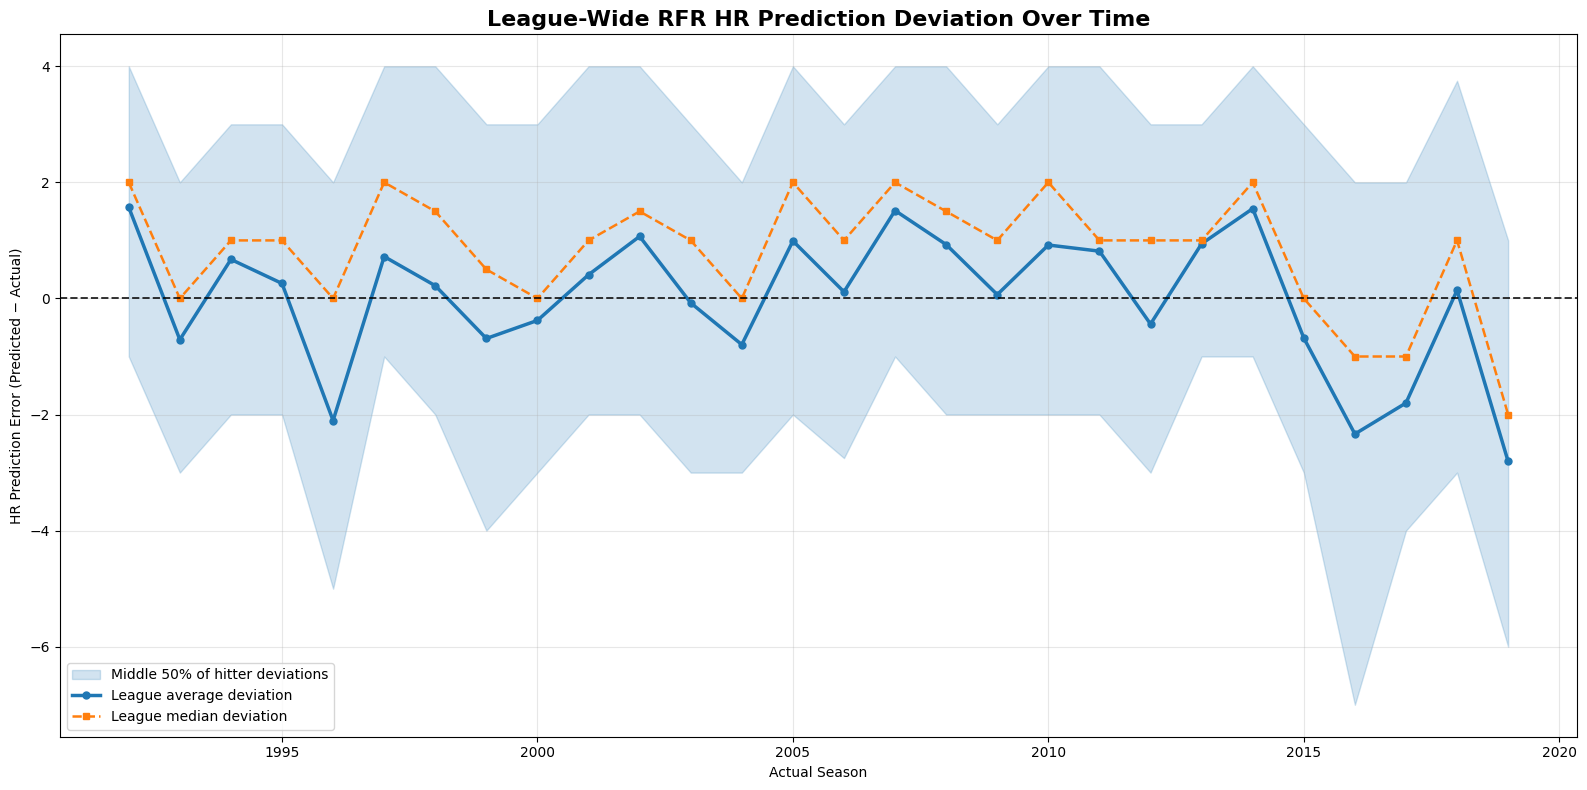

HR deviation summary (5,672 hitter-season predictions):


,Actual_Year,Mean_Error,Median_Error,Q25,Q75,MAE,Hitters
0,1992,1.572165,2.0,-1.0,4.0,3.386598,194
1,1993,-0.71,0.0,-3.0,2.0,3.7,200
2,1994,0.672515,1.0,-2.0,3.0,3.187135,171
3,1995,0.258427,1.0,-2.0,3.0,3.696629,178
4,1996,-2.102857,0.0,-5.0,2.0,4.708571,175
5,1997,0.721951,2.0,-1.0,4.0,3.687805,205
6,1998,0.219626,1.5,-2.0,4.0,4.191589,214
7,1999,-0.689815,0.5,-4.0,3.0,4.25463,216
8,2000,-0.378378,0.0,-3.0,3.0,3.864865,222
9,2001,0.408257,1.0,-2.0,4.0,4.298165,218


In [ ]:
# ============================================================
# LEAGUE-WIDE RFR DEVIATIONS, 1990–2020
# Predicts actual_year from prediction_year = actual_year - 1
# ============================================================

# ============================================================
# LEAGUE-WIDE RFR DEVIATIONS, 1990–2020
# Uses prediction errors returned by predict_next_hitter_stats()
# ============================================================

def build_league_rfr_deviation_data(
    start_prediction_year=1991,
    end_prediction_year=2019,
    hitter_stat_rfr=None,
    hitter_stat_feature_columns=None,
    hitter_stat_target_columns=None,
    model_start_year=1990,
    potential_window=3,
    rating_n_estimators=300
):
    all_deviation_rows = []

    if hitter_stat_rfr is None:
        raise ValueError(
            "Train hitter_stat_rfr before building league deviations."
        )

    error_columns = [
        "H_Prediction_Error",
        "HR_Prediction_Error",
        "BA_Prediction_Error",
        "OBP_Prediction_Error",
        "SLG_Prediction_Error",
        "OPS_Prediction_Error"
    ]

    for prediction_year in range(
        start_prediction_year,
        end_prediction_year + 1
    ):
        actual_year = prediction_year + 1

        if prediction_year in EXCLUDED_YEARS:
            continue

        if actual_year in EXCLUDED_YEARS:
            continue

        try:
            # None means build league-wide ratings and predictions.
            comparison_df = predict_next_hitter_stats(
                target_year=prediction_year,
                selected_team=None,
                hitter_stat_rfr=hitter_stat_rfr,
                hitter_stat_feature_columns=(
                    hitter_stat_feature_columns
                ),
                hitter_stat_target_columns=(
                    hitter_stat_target_columns
                ),
                start_year=model_start_year,
                potential_window=potential_window,
                rating_n_estimators=rating_n_estimators
            ).copy()

        except Exception as error:
            print(
                f"Skipping {prediction_year} -> {actual_year}: "
                f"{type(error).__name__}: {error}"
            )
            continue

        if comparison_df.empty:
            print(
                f"Skipping {prediction_year} -> {actual_year}: "
                "No matched hitters."
            )
            continue

        available_error_columns = [
            column for column in error_columns
            if column in comparison_df.columns
        ]

        if not available_error_columns:
            print(
                f"Skipping {prediction_year} -> {actual_year}: "
                "No prediction-error columns were returned."
            )
            print(
                "Available columns:",
                list(comparison_df.columns)
            )
            continue

        for error_column in available_error_columns:
            stat = error_column.replace(
                "_Prediction_Error",
                ""
            )

            # Only error values are needed for a distribution plot.
            year_df = comparison_df[
                [error_column]
            ].copy()

            year_df = year_df.rename(
                columns={
                    error_column: "Prediction_Error"
                }
            )

            year_df["Prediction_Error"] = pd.to_numeric(
                year_df["Prediction_Error"],
                errors="coerce"
            )

            year_df = year_df.dropna(
                subset=["Prediction_Error"]
            ).copy()

            if year_df.empty:
                continue

            year_df["Prediction_Year"] = prediction_year
            year_df["Actual_Year"] = actual_year
            year_df["Stat"] = stat

            all_deviation_rows.append(year_df)

        print(
            f"Completed {prediction_year} -> {actual_year}: "
            f"{len(comparison_df):,} matched hitters"
        )

    if not all_deviation_rows:
        raise ValueError(
            "No league-wide deviation rows were created."
        )

    league_deviation_df = pd.concat(
        all_deviation_rows,
        ignore_index=True
    )

    return league_deviation_df.sort_values(
        [
            "Actual_Year",
            "Stat"
        ]
    ).reset_index(drop=True)
if "league_rfr_deviation_df" not in globals():
    league_rfr_deviation_df = build_league_rfr_deviation_data(
        start_prediction_year=1991,
        end_prediction_year=2019,
        hitter_stat_rfr=hitter_stat_rfr,
        hitter_stat_feature_columns=(
            hitter_stat_feature_columns
        ),
        hitter_stat_target_columns=(
            hitter_stat_target_columns
        ),
        model_start_year=1990,
        potential_window=3,
        rating_n_estimators=300
    )

    print(
        f"Created {len(league_rfr_deviation_df):,} "
        "league-wide player-stat deviation rows."
    )

else:
    print(
        "Existing league deviation data found. "
        "Rebuild skipped."
    )
# ============================================================
# INTERACTIVE LEAGUE-WIDE DEVIATION DISTRIBUTION GRAPH
# ============================================================

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output


league_stat_dropdown = widgets.Dropdown(
    options=[
        ("Hits", "H"),
        ("Home Runs", "HR"),
        ("Batting Average", "BA"),
        ("On-Base Percentage", "OBP"),
        ("Slugging Percentage", "SLG"),
        ("OPS", "OPS")
    ],
    value="OPS",
    description="Stat category:",
    style={
        "description_width": "initial"
    },
    layout=widgets.Layout(
        width="280px"
    )
)


league_graph_style_dropdown = widgets.Dropdown(
    options=[
        ("Mean deviation over time", "line"),
        ("Deviation distribution by year", "boxplot")
    ],
    value="line",
    description="Graph type:",
    style={
        "description_width": "initial"
    },
    layout=widgets.Layout(
        width="310px"
    )
)


league_graph_button = widgets.Button(
    description="Build Deviation Graph",
    button_style="primary",
    icon="line-chart",
    layout=widgets.Layout(
        width="220px"
    )
)


league_graph_status = widgets.HTML(
    value=(
        "<b>Select a stat category, then click "
        "Build Deviation Graph.</b>"
    )
)


league_graph_output = widgets.Output(
    layout=widgets.Layout(
        border="1px solid #cccccc",
        padding="8px"
    )
)


def build_league_deviation_graph(button):
    selected_stat = league_stat_dropdown.value
    graph_style = league_graph_style_dropdown.value

    if "league_rfr_deviation_df" not in globals():
        league_graph_status.value = (
            "<b style='color:#b22222;'>"
            "League deviation data has not been built yet. "
            "Run the league-deviation build cell first."
            "</b>"
        )
        return

    league_graph_button.disabled = True

    try:
        with league_graph_output:
            clear_output(wait=True)

            graph_df = league_rfr_deviation_df.loc[
                league_rfr_deviation_df["Stat"] == selected_stat
            ].copy()

            graph_df["Prediction_Error"] = pd.to_numeric(
                graph_df["Prediction_Error"],
                errors="coerce"
            )

            graph_df = graph_df.dropna(
                subset=[
                    "Actual_Year",
                    "Prediction_Error"
                ]
            ).copy()

            if graph_df.empty:
                raise ValueError(
                    f"No deviation values exist for {selected_stat}."
                )

            yearly_summary = (
                graph_df
                .groupby(
                    "Actual_Year",
                    as_index=False
                )["Prediction_Error"]
                .agg(
                    Mean_Error="mean",
                    Median_Error="median",
                    Q25=lambda values: values.quantile(0.25),
                    Q75=lambda values: values.quantile(0.75),
                    MAE=lambda values: values.abs().mean(),
                    Hitters="count"
                )
                .sort_values("Actual_Year")
                .reset_index(drop=True)
            )

            if graph_style == "line":
                plt.figure(figsize=(16, 8))

                plt.fill_between(
                    yearly_summary["Actual_Year"],
                    yearly_summary["Q25"],
                    yearly_summary["Q75"],
                    color="#1f77b4",
                    alpha=0.20,
                    label="Middle 50% of hitter deviations"
                )

                plt.plot(
                    yearly_summary["Actual_Year"],
                    yearly_summary["Mean_Error"],
                    marker="o",
                    linewidth=2.5,
                    markersize=5,
                    color="#1f77b4",
                    label="League average deviation"
                )

                plt.plot(
                    yearly_summary["Actual_Year"],
                    yearly_summary["Median_Error"],
                    marker="s",
                    linewidth=1.8,
                    markersize=4,
                    color="#ff7f0e",
                    linestyle="--",
                    label="League median deviation"
                )

                plt.axhline(
                    y=0,
                    color="black",
                    linestyle="--",
                    linewidth=1.4,
                    alpha=0.80
                )

                plt.title(
                    f"League-Wide RFR {selected_stat} "
                    "Prediction Deviation Over Time",
                    fontsize=16,
                    fontweight="bold"
                )

                plt.xlabel("Actual Season")
                plt.ylabel(
                    f"{selected_stat} Prediction Error "
                    "(Predicted − Actual)"
                )

                plt.grid(alpha=0.30)
                plt.legend()
                plt.tight_layout()
                plt.show()

            else:
                years = sorted(
                    graph_df["Actual_Year"]
                    .unique()
                    .tolist()
                )

                distribution_data = [
                    graph_df.loc[
                        graph_df["Actual_Year"] == year,
                        "Prediction_Error"
                    ].dropna().values
                    for year in years
                ]

                plt.figure(figsize=(20, 8))

                boxplot = plt.boxplot(
                    distribution_data,
                    tick_labels=years,
                    patch_artist=True,
                    showfliers=False
                )

                for box in boxplot["boxes"]:
                    box.set(
                        facecolor="#1f77b4",
                        alpha=0.45
                    )

                plt.axhline(
                    y=0,
                    color="black",
                    linestyle="--",
                    linewidth=1.4,
                    alpha=0.80
                )

                plt.title(
                    f"League-Wide RFR {selected_stat} "
                    "Deviation Distribution by Actual Season",
                    fontsize=16,
                    fontweight="bold"
                )

                plt.xlabel("Actual Season")
                plt.ylabel(
                    f"{selected_stat} Prediction Error "
                    "(Predicted − Actual)"
                )

                plt.xticks(rotation=45)
                plt.grid(axis="y", alpha=0.30)
                plt.tight_layout()
                plt.show()

            print(
                f"{selected_stat} deviation summary "
                f"({len(graph_df):,} hitter-season predictions):"
            )

            display(yearly_summary)

        league_graph_status.value = (
            f"<b style='color:#228B22;'>Finished.</b> "
            f"Displayed league-wide {selected_stat} "
            "prediction deviations over time."
        )

    except Exception as error:
        league_graph_status.value = (
            "<b style='color:#b22222;'>"
            "Could not build the league deviation graph."
            "</b>"
        )

        with league_graph_output:
            clear_output(wait=True)
            print(
                f"Error type: {type(error).__name__}"
            )
            print(
                f"Error message: {error}"
            )

    finally:
        league_graph_button.disabled = False


league_graph_button.on_click(
    build_league_deviation_graph
)

league_graph_controls = widgets.HBox([
    league_stat_dropdown,
    league_graph_style_dropdown,
    league_graph_button
])

display(
    league_graph_controls,
    league_graph_status,
    league_graph_output
)

In [ ]:
def fielding_AI_rating(df):
    df = df.copy()
    features = ["PO", "A", "E", "FldPct"]
    # drop rows lacking features
    df = df.dropna(subset=features).reset_index(drop=True)
    if df.shape[0] == 0:
        raise ValueError("No rows with complete fielding data to rate")

    # raw fielding score (vectorized)
    raw = (df["FldPct"] * 50 + (df["A"] + df["PO"]) * 0.1 - df["E"] * 2).clip(lower=0, upper=100)
    df["raw_fielding_score"] = raw

    # train/test
    X = df[features]
    y = df["raw_fielding_score"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Fielding model R^2 = {r2_score(y_test, y_pred):.3f}, RMSE = {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

    df["fielding_raw_pred"] = model.predict(X)

    # convert to 20-80 scale and round to nearest 5
    def scale_to_20_80(value):
        scaled = 20 + (value * 0.6)
        return round(min(max(scaled, 20), 80) / 5) * 5

    df["fielding_20_80"] = df["fielding_raw_pred"].apply(scale_to_20_80)

    def fielding_tier(rating):
        if rating >= 70:
            return "Elite"
        elif rating >= 55:
            return "Good"
        elif rating >= 45:
            return "Average"
        else:
            return "Poor"

    df["fielding_grade"] = df["fielding_20_80"].apply(fielding_tier)
    return df

In [ ]:
# @title
def era_AI_prediction():
    def manual_era_adjustment(row):
        base_era = row["ERA"]
        age = row["Age"]
        potential = row["Potential"]
        ovr = row["OVR"]

        age_factor = 1.0
        if age < 22:
            age_factor += np.random.uniform(0.02, 0.08) * (22 - age)
        elif age < 26:
            age_factor += np.random.uniform(-0.01, 0.06) * (26 - age)
        elif age < 28:
            age_factor += np.random.uniform(-0.02, 0.04) * (28 - age)
        elif age < 30:
            age_factor += np.random.uniform(-0.02, 0.02) * (age - 30)
        elif age < 33:
            age_factor -= np.random.uniform(0.0, 0.04) * (age - 30)
        elif age < 35:
            age_factor -= np.random.uniform(0.0, 0.06) * (age - 30)
        else:
            age_factor -= np.random.uniform(0.02, 0.06) * (age - 30)

        potential_factor = 1 + (potential - ovr) * 0.005
        adjusted_era = base_era / age_factor / potential_factor

        return min(max(adjusted_era, 0), 1)

    df["ERA_manual_adjusted"] = df.apply(manual_era_adjustment, axis=1)
    df.dropna(subset=features + ["ERA_manual_adjusted"], inplace=True)

    X_slg = df[features]
    y_slg = df["ERA_manual_adjusted"]

    X_train, X_test, y_train, y_test = train_test_split(X_slg, y_slg, test_size=0.2, random_state=42)

    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    print(f"RF Model R²: {r2_score(y_test, y_pred):.3f}")
    print(f"RF Model RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
    df["ERA_predicted_AI"] = rf_model.predict(df[features]).round(3)

In [ ]:
# @title
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from IPython.display import display


# ============================================================
# 1. BUILD HISTORICAL HITTER CONTRACT MODEL
# ============================================================

def build_hitter_contract_model(
    start_year=1990,
    end_year=2023,
    n_estimators=400
):
    salaries_clean = pd.read_csv("Salaries.csv")

    salaries_clean["yearID"] = pd.to_numeric(
        salaries_clean["yearID"],
        errors="coerce"
    )

    salaries_clean["salary"] = pd.to_numeric(
        salaries_clean["salary"],
        errors="coerce"
    )

    salaries_clean = salaries_clean.dropna(
        subset=[
            "playerID",
            "yearID",
            "salary"
        ]
    ).copy()

    salaries_clean["yearID"] = (
        salaries_clean["yearID"]
        .astype(int)
    )

    salaries_clean = (
        salaries_clean
        .groupby(
            ["playerID", "yearID"],
            as_index=False
        )["salary"]
        .sum()
    )

    salary_min_year = int(
        salaries_clean["yearID"].min()
    )

    salary_max_year = int(
        salaries_clean["yearID"].max()
    )

    # A next-season salary target requires year + 1 salary data.
    effective_start_year = max(
        start_year,
        salary_min_year
    )

    effective_end_year = min(
        end_year,
        salary_max_year - 1
    )

    if effective_start_year > effective_end_year:
        raise ValueError(
            "There are not enough salary years to train "
            "a next-season contract model."
        )

    league_salary = (
        salaries_clean
        .groupby(
            "yearID",
            as_index=False
        )["salary"]
        .agg(
            League_Median_Salary="median",
            League_Mean_Salary="mean"
        )
        .sort_values("yearID")
        .reset_index(drop=True)
    )

    league_salary["Median_5Y_Ago"] = (
        league_salary["League_Median_Salary"]
        .shift(5)
    )

    league_salary["Inflation_5Y"] = np.where(
        league_salary["Median_5Y_Ago"] > 0,
        league_salary["League_Median_Salary"]
        / league_salary["Median_5Y_Ago"],
        1.0
    )

    league_salary["Inflation_5Y"] = (
        league_salary["Inflation_5Y"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(1.0)
    )

    # Standardize the season column name once.
    league_salary = league_salary.rename(
        columns={
            "yearID": "Season"
        }
    )

    historical_rows = []

    for year in range(
        effective_start_year,
        effective_end_year + 1
    ):
        if year in EXCLUDED_YEARS:
            continue

        if year + 1 in EXCLUDED_YEARS:
            continue

        try:
            current_df = hittingStats(year)

        except Exception:
            continue

        if current_df is None or current_df.empty:
            continue

        required_cols = [
            "playerID",
            "Age",
            "G",
            "AB",
            "H",
            "BB",
            "HR",
            "2B",
            "SO",
            "BA",
            "OBP",
            "SLG",
            "OPS"
        ]

        missing = [
            col for col in required_cols
            if col not in current_df.columns
        ]

        if missing:
            continue

        current_df = current_df[
            required_cols
        ].copy()

        current_df["Season"] = year

        historical_rows.append(current_df)

    if not historical_rows:
        raise ValueError(
            "No historical hitter data was available "
            "for contract-model training."
        )

    historical_df = pd.concat(
        historical_rows,
        ignore_index=True
    )

    current_salaries = salaries_clean.rename(
        columns={
            "yearID": "Season",
            "salary": "CurrentSeasonSalary"
        }
    )

    next_salaries = salaries_clean.copy()

    next_salaries["yearID"] = (
        next_salaries["yearID"] - 1
    )

    next_salaries = next_salaries.rename(
        columns={
            "yearID": "Season",
            "salary": "NextSeasonSalary"
        }
    )

    salary_training_df = historical_df.merge(
        current_salaries,
        on=[
            "playerID",
            "Season"
        ],
        how="inner",
        validate="one_to_one"
    )

    salary_training_df = salary_training_df.merge(
        next_salaries,
        on=[
            "playerID",
            "Season"
        ],
        how="inner",
        validate="one_to_one"
    )

    salary_training_df = salary_training_df.merge(
        league_salary,
        on="Season",
        how="left",
        validate="many_to_one"
    )

    contract_features = [
        "Age",
        "G",
        "AB",
        "H",
        "BB",
        "HR",
        "2B",
        "SO",
        "BA",
        "OBP",
        "SLG",
        "OPS",
        "CurrentSeasonSalary",
        "League_Median_Salary",
        "League_Mean_Salary",
        "Inflation_5Y"
    ]

    salary_training_df = salary_training_df.dropna(
        subset=contract_features + [
            "NextSeasonSalary"
        ]
    ).copy()

    if salary_training_df.empty:
        raise ValueError(
            "No historical player-seasons remained after "
            "matching stats to current and next-season salary data."
        )

    salary_training_df["LogNextSeasonSalary"] = np.log1p(
        salary_training_df["NextSeasonSalary"]
    )

    contract_model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=42,
        min_samples_leaf=3,
        max_features=0.8,
        n_jobs=-1
    )

    contract_model.fit(
        salary_training_df[contract_features],
        salary_training_df["LogNextSeasonSalary"]
    )

    return (
        contract_model,
        contract_features,
        league_salary,
        salary_training_df
    )


# ============================================================
# 2. PREDICT HITTER CONTRACT VALUE
# ============================================================

def predict_hitter_contract_values(
    ratings_df,
    target_year,
    contract_model,
    contract_features,
    league_salary
):
    prediction_df = ratings_df.copy()

    if prediction_df.empty:
        raise ValueError(
            "The hitter ratings dataframe is empty."
        )

    if "playerID" not in prediction_df.columns:
        raise ValueError(
            "ratings_df must contain playerID."
        )

    salaries_clean = pd.read_csv("Salaries.csv")

    salaries_clean["yearID"] = pd.to_numeric(
        salaries_clean["yearID"],
        errors="coerce"
    )

    salaries_clean["salary"] = pd.to_numeric(
        salaries_clean["salary"],
        errors="coerce"
    )

    salaries_clean = salaries_clean.dropna(
        subset=[
            "playerID",
            "yearID",
            "salary"
        ]
    ).copy()

    salaries_clean["yearID"] = (
        salaries_clean["yearID"]
        .astype(int)
    )

    current_salaries = (
        salaries_clean.loc[
            salaries_clean["yearID"] == target_year
        ]
        .groupby(
            "playerID",
            as_index=False
        )["salary"]
        .sum()
        .rename(
            columns={
                "salary": "CurrentSeasonSalary"
            }
        )
    )

    prediction_df = prediction_df.merge(
        current_salaries,
        on="playerID",
        how="left",
        validate="one_to_one"
    )

    prediction_df["CurrentSeasonSalary"] = (
        pd.to_numeric(
            prediction_df["CurrentSeasonSalary"],
            errors="coerce"
        )
        .fillna(400000)
        .clip(lower=400000)
    )

    league_context = league_salary.loc[
        league_salary["Season"] == target_year
    ].copy()

    if league_context.empty:
        league_context = league_salary.tail(1).copy()

    league_context = league_context.iloc[0]

    prediction_df["League_Median_Salary"] = (
        league_context["League_Median_Salary"]
    )

    prediction_df["League_Mean_Salary"] = (
        league_context["League_Mean_Salary"]
    )

    prediction_df["Inflation_5Y"] = (
        league_context["Inflation_5Y"]
    )

    for col in contract_features:
        if col not in prediction_df.columns:
            prediction_df[col] = 0

        prediction_df[col] = pd.to_numeric(
            prediction_df[col],
            errors="coerce"
        ).fillna(0)

    prediction_df["PredictedContractValue"] = np.expm1(
        contract_model.predict(
            prediction_df[contract_features]
        )
    )

    prediction_df["PredictedContractValue"] = (
        prediction_df["PredictedContractValue"]
        .clip(lower=400000)
        .round()
        .astype("Int64")
    )

    return prediction_df


# ============================================================
# 3. PREDICT CONTRACT LENGTH
# ============================================================

def predict_hitter_contract_length(df):
    df = df.copy()

    age = pd.to_numeric(
        df["Age"],
        errors="coerce"
    ).fillna(30)

    ovr = pd.to_numeric(
        df["OVR"],
        errors="coerce"
    ).fillna(70)

    potential = pd.to_numeric(
        df["Potential"],
        errors="coerce"
    ).fillna(70)

    projected_ovr = pd.to_numeric(
        df["Projected_OVR"],
        errors="coerce"
    ).fillna(ovr)

    ops = pd.to_numeric(
        df["OPS"],
        errors="coerce"
    ).fillna(0.650)

    games = pd.to_numeric(
        df["G"],
        errors="coerce"
    ).fillna(0)

    age_score = np.select(
        [
            age <= 22,
            age <= 25,
            age <= 28,
            age <= 31,
            age <= 34,
            age <= 37
        ],
        [
            7.0,
            6.0,
            4.5,
            3.0,
            2.0,
            1.0
        ],
        default=0.0
    )

    performance_score = (
        (ovr - 70) / 8
        + (potential - ovr) / 10
        + (projected_ovr - ovr) / 10
        + np.clip(
            (ops - 0.700) * 4,
            -1,
            1
        )
        + np.clip(
            games / 162,
            0,
            1
        )
    )

    contract_years = np.round(
        age_score + performance_score
    )

    df["ProjectedContractYears"] = (
        pd.Series(
            contract_years,
            index=df.index
        )
        .clip(lower=1, upper=8)
        .astype(int)
    )

    return df


# ============================================================
# 4. BUILD FINAL CONTRACT TABLE
# ============================================================

def build_hitter_contract_table(
    ratings_df,
    target_year,
    contract_model,
    contract_features,
    league_salary
):
    contract_df = predict_hitter_contract_values(
        ratings_df=ratings_df,
        target_year=target_year,
        contract_model=contract_model,
        contract_features=contract_features,
        league_salary=league_salary
    )

    contract_df = predict_hitter_contract_length(
        contract_df
    )

    contract_df = contract_df.sort_values(
        "PredictedContractValue",
        ascending=False
    ).reset_index(drop=True)

    contract_df["CurrentSeasonSalary"] = (
        contract_df["CurrentSeasonSalary"]
        .round()
        .astype("Int64")
    )

    display_columns = [
        "Name",
        "Team",
        "PrimaryPosition",
        "Age",
        "OVR",
        "Projected_OVR",
        "Potential",
        "OPS",
        "HR",
        "CurrentSeasonSalary",
        "PredictedContractValue",
        "ProjectedContractYears"
    ]

    display_columns = [
        col for col in display_columns
        if col in contract_df.columns
    ]

    return contract_df[display_columns].copy()


# ============================================================
# 5. TRAIN CONTRACT MODEL ONCE
# ============================================================

contract_model, contract_features, league_salary, contract_training_df = (
    build_hitter_contract_model(
        start_year=1990,
        end_year=2023,
        n_estimators=500
    )
)

print(
    f"Contract model trained on "
    f"{len(contract_training_df):,} hitter salary rows."
)

Contract model trained on 7,403 hitter salary rows.


In [ ]:
# Example: build ratings for the 2012 Yankees.
ratings_df = build_hitter_ratings(
    target_year=2012,
    selected_team="NYA",
    start_year=1990,
    potential_window=3,
    n_estimators=300,
    show_histograms=False
)

# Create salary and contract-length estimates.
contract_table = build_hitter_contract_table(
    ratings_df=ratings_df,
    target_year=2012,
    contract_model=contract_model,
    contract_features=contract_features,
    league_salary=league_salary
)

# Display the completed contract table.
display(contract_table)

,Name,Team,PrimaryPosition,Age,OVR,Projected_OVR,Potential,OPS,HR,CurrentSeasonSalary,PredictedContractValue,ProjectedContractYears
0,Alex Rodriguez,NYA,3B,36,78,77,78,0.783,18,30000000,26345415,3
1,Mark Teixeira,NYA,1B,32,83,80,84,0.807,24,23125000,22782673,5
2,Robinson Cano,NYA,2B,29,89,87,90,0.929,33,14000000,15747471,7
3,Derek Jeter,NYA,SS,38,74,73,74,0.791,15,15729364,14423720,2
4,Curtis Granderson,NYA,OF,31,90,80,90,0.811,43,10000000,12993509,6
5,Nick Swisher,NYA,OF,31,80,78,81,0.837,24,10250000,11586018,6
6,Ichiro Suzuki,NYA/SEA,OF,38,76,77,76,0.696,9,18000000,10506360,2
7,Russell Martin,NYA,C,29,80,81,84,0.713,21,7500000,6406943,6
8,Raul Ibanez,NYA,OF,40,80,77,80,0.761,19,1100000,2322351,2
9,Casey McGehee,NYA/PIT,1B,29,80,82,86,0.643,9,2537500,2300805,6


In [ ]:
contract_table = build_hitter_contract_table(
    ratings_df=final_df,
    target_year=target_year,
    contract_model=contract_model,
    contract_features=contract_features,
    league_salary=league_salary
)

display(contract_table)

NameError: name 'final_df' is not defined

In [ ]:
if __name__ == "__main__":
    # your existing code loading CSVs and generating df
    BATTING_CSV = pd.read_csv("Batting.csv")
    FIELDING_CSV = pd.read_csv("Fielding.csv")
    PEOPLE_CSV = pd.read_csv("People.csv")
    RANDOM_STATE = 42
    year = 2024
    df = battingStats(year, "Batting.csv", "Fielding.csv", "People.csv")
    df = ovrAndPotential(df)
    df["Predicted_OBP"] = obp_AI_prediction(df)
    df["Predicted_SLG"] = slg_AI_prediction(df)
    df["Predicted_HR"] = hr_AI_prediction(df)
    df = fielding_AI_rating(df)

    # Apply the projected contract value function row-wise

    display_cols = [
        "Name", "Age", "PrimaryPosition", "OVR", "Potential", "G",
        "OBP_manual_adjusted", "SLG_manual_adjusted", "HR_manual_adjusted",
        "BA", "OBP", "SLG", "BB", "HR", "SO", "E",
        "FldPct", "fielding_20_80", "fielding_grade", "ProjectedContractValue"
    ]

    display_cols = [c for c in display_cols if c in df.columns]
    df_display = df[display_cols].sort_values(by="OVR", ascending=False).head(200).reset_index(drop=True)

    display(df_display.head(100))


NameError: name 'ovrAndPotential' is not defined

In [ ]:
from matplotlib import pyplot as plt

df["Age"].plot(kind="hist", bins=20, title="Age")
plt.gca().spines[["top", "right"]].set_visible(False)

In [ ]:
# @title
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from IPython.display import display


# ============================================================
# 1. YEAR-TO-YEAR HITTER DEVIATION TABLE
# ============================================================

def compute_hitter_deviations_for_year(
    year,
    start_year=1990,
    potential_window=3,
    n_estimators=300
):
    if year in EXCLUDED_YEARS:
        raise ValueError(
            f"{year} is excluded because it is a shortened season."
        )

    if year - 1 in EXCLUDED_YEARS:
        raise ValueError(
            f"{year - 1} is excluded because it is a shortened season."
        )

    if year <= start_year:
        raise ValueError(
            f"Choose a year after {start_year} "
            "so a previous season exists."
        )

    previous_ratings = build_hitter_ratings(
        target_year=year - 1,
        selected_team=None,
        start_year=start_year,
        potential_window=potential_window,
        n_estimators=n_estimators,
        show_histograms=False
    ).copy()

    current_ratings = build_hitter_ratings(
        target_year=year,
        selected_team=None,
        start_year=start_year,
        potential_window=potential_window,
        n_estimators=n_estimators,
        show_histograms=False
    ).copy()

    required_cols = [
        "playerID",
        "Name",
        "Team",
        "Age",
        "OVR",
        "Formula_OVR",
        "Projected_OVR",
        "Potential",
        "G",
        "AB",
        "H",
        "BB",
        "HR",
        "2B",
        "SO",
        "BA",
        "OBP",
        "SLG",
        "OPS"
    ]

    missing_previous = [
        col for col in required_cols
        if col not in previous_ratings.columns
    ]

    missing_current = [
        col for col in required_cols
        if col not in current_ratings.columns
    ]

    if missing_previous:
        raise ValueError(
            f"Previous ratings are missing columns: "
            f"{missing_previous}"
        )

    if missing_current:
        raise ValueError(
            f"Current ratings are missing columns: "
            f"{missing_current}"
        )

    previous_df = previous_ratings[
        required_cols
    ].copy()

    current_df = current_ratings[
        required_cols
    ].copy()

    merged = previous_df.merge(
        current_df,
        on="playerID",
        how="inner",
        suffixes=(
            f"_{year - 1}",
            f"_{year}"
        ),
        validate="one_to_one"
    )

    merged["Name"] = merged[
        f"Name_{year}"
    ].fillna(
        merged[f"Name_{year - 1}"]
    )

    merged["Team"] = merged[
        f"Team_{year}"
    ].fillna(
        merged[f"Team_{year - 1}"]
    )

    merged["Age"] = merged[
        f"Age_{year}"
    ].fillna(
        merged[f"Age_{year - 1}"]
    )

    rating_stats = [
        "OVR",
        "Formula_OVR",
        "Projected_OVR",
        "Potential"
    ]

    offensive_stats = [
        "G",
        "AB",
        "H",
        "BB",
        "HR",
        "2B",
        "SO",
        "BA",
        "OBP",
        "SLG",
        "OPS"
    ]

    for stat in rating_stats:
        merged[f"{stat}_deviation"] = (
            pd.to_numeric(
                merged[f"{stat}_{year}"],
                errors="coerce"
            )
            - pd.to_numeric(
                merged[f"{stat}_{year - 1}"],
                errors="coerce"
            )
        )

    for stat in offensive_stats:
        merged[f"{stat}_actual_change"] = (
            pd.to_numeric(
                merged[f"{stat}_{year}"],
                errors="coerce"
            )
            - pd.to_numeric(
                merged[f"{stat}_{year - 1}"],
                errors="coerce"
            )
        )

    merged["Projected_OVR_error"] = (
        pd.to_numeric(
            merged[f"Formula_OVR_{year}"],
            errors="coerce"
        )
        - pd.to_numeric(
            merged[f"Projected_OVR_{year - 1}"],
            errors="coerce"
        )
    )

    merged["Projected_OVR_absolute_error"] = (
        merged["Projected_OVR_error"]
        .abs()
    )

    return merged


# ============================================================
# 2. SPLIT DEVIATION TABLES
# ============================================================

def build_hitter_deviation_tables(
    df_deviation,
    year
):
    # --------------------------------------------------------
    # TABLE 1: OVR / POTENTIAL / RATING-RELATED RESULTS
    # --------------------------------------------------------
    rating_display_cols = [
        "playerID",
        "Name",
        "Team",
        "Age",

        f"OVR_{year - 1}",
        f"OVR_{year}",
        "OVR_deviation",

        f"Formula_OVR_{year - 1}",
        f"Formula_OVR_{year}",
        "Formula_OVR_deviation",

        f"Projected_OVR_{year - 1}",
        f"Projected_OVR_{year}",
        "Projected_OVR_deviation",

        f"Potential_{year - 1}",
        f"Potential_{year}",
        "Potential_deviation",

        "Projected_OVR_error",
        "Projected_OVR_absolute_error"
    ]

    # --------------------------------------------------------
    # TABLE 2: SHORTENED BATTING STAT DEVIATION TABLE
    #
    # Shows only H, HR, BA, OBP, SLG, and OPS.
    # Does NOT display G, AB, BB, 2B, or SO.
    # --------------------------------------------------------
    stat_display_cols = [
        "playerID",
        "Name",
        "Team",
        "Age",

        f"H_{year - 1}",
        f"H_{year}",
        "H_actual_change",

        f"HR_{year - 1}",
        f"HR_{year}",
        "HR_actual_change",

        f"BA_{year - 1}",
        f"BA_{year}",
        "BA_actual_change",

        f"OBP_{year - 1}",
        f"OBP_{year}",
        "OBP_actual_change",

        f"SLG_{year - 1}",
        f"SLG_{year}",
        "SLG_actual_change",

        f"OPS_{year - 1}",
        f"OPS_{year}",
        "OPS_actual_change"
    ]

    rating_display_cols = [
        col for col in rating_display_cols
        if col in df_deviation.columns
    ]

    stat_display_cols = [
        col for col in stat_display_cols
        if col in df_deviation.columns
    ]

    rating_deviation_table = (
        df_deviation[rating_display_cols]
        .sort_values(
            by="OVR_deviation",
            ascending=False
        )
        .reset_index(drop=True)
    )

    stat_deviation_table = (
        df_deviation[stat_display_cols]
        .sort_values(
            by="OPS_actual_change",
            ascending=False
        )
        .reset_index(drop=True)
        .rename(
            columns={
                f"H_{year - 1}": "Previous_H",
                f"H_{year}": "Actual_H",
                "H_actual_change": "H_Change",

                f"HR_{year - 1}": "Previous_HR",
                f"HR_{year}": "Actual_HR",
                "HR_actual_change": "HR_Change",

                f"BA_{year - 1}": "Previous_BA",
                f"BA_{year}": "Actual_BA",
                "BA_actual_change": "BA_Change",

                f"OBP_{year - 1}": "Previous_OBP",
                f"OBP_{year}": "Actual_OBP",
                "OBP_actual_change": "OBP_Change",

                f"SLG_{year - 1}": "Previous_SLG",
                f"SLG_{year}": "Actual_SLG",
                "SLG_actual_change": "SLG_Change",

                f"OPS_{year - 1}": "Previous_OPS",
                f"OPS_{year}": "Actual_OPS",
                "OPS_actual_change": "OPS_Change"
            }
        )
    )

    return (
        rating_deviation_table,
        stat_deviation_table
    )


# ============================================================
# 3. BUILD NEXT-SEASON HITTER STAT MODEL
# ============================================================

def build_hitter_stat_prediction_model(
    start_year=1990,
    end_year=2023,
    potential_window=3,
    rating_n_estimators=300,
    stat_model_n_estimators=400
):
    training_rows = []

    feature_columns = [
        "Age",
        "OVR",
        "Formula_OVR",
        "Projected_OVR",
        "Potential",
        "G",
        "AB",
        "H",
        "BB",
        "HR",
        "2B",
        "SO",
        "BA",
        "OBP",
        "SLG",
        "OPS"
    ]

    target_stat_columns = [
        "G",
        "AB",
        "H",
        "BB",
        "HR",
        "2B",
        "SO"
    ]

    for year in range(start_year, end_year):
        next_year = year + 1

        if year in EXCLUDED_YEARS:
            continue

        if next_year in EXCLUDED_YEARS:
            continue

        try:
            current_ratings = build_hitter_ratings(
                target_year=year,
                selected_team=None,
                start_year=start_year,
                potential_window=potential_window,
                n_estimators=rating_n_estimators,
                show_histograms=False
            ).copy()

            next_year_stats = hittingStats(
                next_year
            ).copy()

        except Exception:
            continue

        if current_ratings.empty:
            continue

        if next_year_stats.empty:
            continue

        required_current = [
            "playerID"
        ] + feature_columns

        required_next = [
            "playerID"
        ] + target_stat_columns

        missing_current = [
            col for col in required_current
            if col not in current_ratings.columns
        ]

        missing_next = [
            col for col in required_next
            if col not in next_year_stats.columns
        ]

        if missing_current or missing_next:
            continue

        current_df = current_ratings[
            required_current
        ].copy()

        next_df = next_year_stats[
            required_next
        ].copy()

        next_df = next_df.rename(
            columns={
                col: f"Next_{col}"
                for col in target_stat_columns
            }
        )

        year_training_df = current_df.merge(
            next_df,
            on="playerID",
            how="inner",
            validate="one_to_one"
        )

        if year_training_df.empty:
            continue

        year_training_df["Season"] = year

        training_rows.append(year_training_df)

    if not training_rows:
        raise ValueError(
            "No historical hitter seasons were available "
            "to train the stat model."
        )

    stat_training_df = pd.concat(
        training_rows,
        ignore_index=True
    )

    target_columns = [
        f"Next_{col}"
        for col in target_stat_columns
    ]

    numeric_columns = (
        feature_columns
        + target_columns
    )

    for column in numeric_columns:
        stat_training_df[column] = pd.to_numeric(
            stat_training_df[column],
            errors="coerce"
        )

    stat_training_df = stat_training_df.dropna(
        subset=numeric_columns
    ).copy()

    if stat_training_df.empty:
        raise ValueError(
            "No usable rows remained after cleaning "
            "the stat prediction training data."
        )

    stat_model = RandomForestRegressor(
        n_estimators=stat_model_n_estimators,
        random_state=42,
        min_samples_leaf=3,
        max_features=0.8,
        n_jobs=-1
    )

    stat_model.fit(
        stat_training_df[feature_columns],
        stat_training_df[target_columns]
    )

    return (
        stat_model,
        feature_columns,
        target_columns,
        stat_training_df
    )


# ============================================================
# 4. PROJECT NEXT-SEASON HITTER STATS
# ============================================================

def predict_hitter_next_season_stats(
    ratings_df,
    stat_model,
    stat_feature_columns,
    stat_target_columns
):
    prediction_df = ratings_df.copy()

    if prediction_df.empty:
        raise ValueError(
            "ratings_df is empty."
        )

    missing_features = [
        col for col in stat_feature_columns
        if col not in prediction_df.columns
    ]

    if missing_features:
        raise ValueError(
            f"ratings_df is missing columns: "
            f"{missing_features}"
        )

    for column in stat_feature_columns:
        prediction_df[column] = pd.to_numeric(
            prediction_df[column],
            errors="coerce"
        ).fillna(0)

    predicted_values = stat_model.predict(
        prediction_df[stat_feature_columns]
    )

    predicted_df = pd.DataFrame(
        predicted_values,
        columns=stat_target_columns,
        index=prediction_df.index
    )

    prediction_df = pd.concat(
        [
            prediction_df,
            predicted_df
        ],
        axis=1
    )

    count_columns = [
        "Next_G",
        "Next_AB",
        "Next_H",
        "Next_BB",
        "Next_HR",
        "Next_2B",
        "Next_SO"
    ]

    for column in count_columns:
        prediction_df[column] = (
            prediction_df[column]
            .clip(lower=0)
            .round()
            .astype("Int64")
        )

    prediction_df["Next_G"] = (
        prediction_df["Next_G"]
        .clip(upper=162)
    )

    prediction_df["Next_AB"] = (
        prediction_df["Next_AB"]
        .clip(upper=750)
    )

    prediction_df["Next_H"] = np.minimum(
        prediction_df["Next_H"],
        prediction_df["Next_AB"]
    )

    prediction_df["Next_HR"] = np.minimum(
        prediction_df["Next_HR"],
        prediction_df["Next_H"]
    )

    prediction_df["Next_2B"] = np.minimum(
        prediction_df["Next_2B"],
        prediction_df["Next_H"]
    )

    # Predict triples only as a small approximation from doubles.
    # This lets total bases and slugging percentage be calculated.
    prediction_df["Next_3B"] = (
        prediction_df["Next_2B"]
        .astype(float)
        .mul(0.08)
        .round()
        .clip(lower=0)
        .astype("Int64")
    )

    # Ensure extra-base hit totals cannot exceed total hits.
    extra_base_hits = (
        prediction_df["Next_2B"]
        + prediction_df["Next_3B"]
        + prediction_df["Next_HR"]
    )

    too_many_xbh = extra_base_hits > prediction_df["Next_H"]

    if too_many_xbh.any():
        scale = (
            prediction_df.loc[
                too_many_xbh,
                "Next_H"
            ]
            / extra_base_hits.loc[too_many_xbh]
        )

        for column in [
            "Next_2B",
            "Next_3B",
            "Next_HR"
        ]:
            prediction_df.loc[
                too_many_xbh,
                column
            ] = (
                prediction_df.loc[
                    too_many_xbh,
                    column
                ]
                .astype(float)
                .mul(scale)
                .round()
                .astype("Int64")
            )

    prediction_df["Next_1B"] = (
        prediction_df["Next_H"]
        - prediction_df["Next_2B"]
        - prediction_df["Next_3B"]
        - prediction_df["Next_HR"]
    ).clip(lower=0)

    prediction_df["Next_TB"] = (
        prediction_df["Next_1B"]
        + 2 * prediction_df["Next_2B"]
        + 3 * prediction_df["Next_3B"]
        + 4 * prediction_df["Next_HR"]
    )

    prediction_df["Next_BA"] = np.where(
        prediction_df["Next_AB"] > 0,
        prediction_df["Next_H"]
        / prediction_df["Next_AB"],
        0
    )

    prediction_df["Next_OBP"] = np.where(
        (
            prediction_df["Next_AB"]
            + prediction_df["Next_BB"]
        ) > 0,
        (
            prediction_df["Next_H"]
            + prediction_df["Next_BB"]
        )
        / (
            prediction_df["Next_AB"]
            + prediction_df["Next_BB"]
        ),
        0
    )

    prediction_df["Next_SLG"] = np.where(
        prediction_df["Next_AB"] > 0,
        prediction_df["Next_TB"]
        / prediction_df["Next_AB"],
        0
    )

    prediction_df["Next_OPS"] = (
        prediction_df["Next_OBP"]
        + prediction_df["Next_SLG"]
    )

    rate_columns = [
        "Next_BA",
        "Next_OBP",
        "Next_SLG",
        "Next_OPS"
    ]

    for column in rate_columns:
        prediction_df[column] = (
            prediction_df[column]
            .clip(lower=0)
            .round(3)
        )

    return prediction_df


# ============================================================
# 5. CREATE A CLEAN PROJECTED-STAT DISPLAY TABLE
# ============================================================

# ============================================================
# REPLACE THE FINAL STAT-PREDICTION DISPLAY FUNCTION
# ============================================================

def build_hitter_stat_prediction_table(
    ratings_df,
    stat_model,
    stat_feature_columns,
    stat_target_columns
):
    projected_df = predict_hitter_next_season_stats(
        ratings_df=ratings_df,
        stat_model=stat_model,
        stat_feature_columns=stat_feature_columns,
        stat_target_columns=stat_target_columns
    )

    # Keep the full projected_df internally.
    # Only select a concise set of columns for display.
    display_columns = [
        "Name",
        "Team",
        "PrimaryPosition",
        "Age",
        "OVR",
        "Formula_OVR",
        "Projected_OVR",
        "Potential",

        # Actual selected-season stats.
        "G",
        "AB",
        "H",
        "HR",
        "BB",
        "OPS",

        # Predicted next-season stats.
        "Next_H",
        "Next_HR",
        "Next_BA",
        "Next_OBP",
        "Next_SLG",
        "Next_OPS"
    ]

    display_columns = [
        col for col in display_columns
        if col in projected_df.columns
    ]

    display_df = projected_df[
        display_columns
    ].copy()

    display_df = display_df.rename(
        columns={
            "G": "Actual_G",
            "AB": "Actual_AB",
            "H": "Actual_H",
            "HR": "Actual_HR",
            "BB": "Actual_BB",
            "OPS": "Actual_OPS",

            "Next_H": "Predicted_H",
            "Next_HR": "Predicted_HR",
            "Next_BA": "Predicted_BA",
            "Next_OBP": "Predicted_OBP",
            "Next_SLG": "Predicted_SLG",
            "Next_OPS": "Predicted_OPS"
        }
    )

    sort_column = (
        "Predicted_OPS"
        if "Predicted_OPS" in display_df.columns
        else "OVR"
    )

    display_df = display_df.sort_values(
        by=sort_column,
        ascending=False
    ).reset_index(drop=True)

    return display_df

# ============================================================
# 6. RFR BACKTEST TABLE:
# PREDICT NEXT-YEAR STATS AND COMPARE TO ACTUAL RESULTS
# ============================================================

def build_hitter_stat_backtest_table(
    target_year,
    stat_model,
    stat_feature_columns,
    stat_target_columns,
    start_year=1990,
    potential_window=3,
    rating_n_estimators=300,
    selected_team=None
):
    next_year = target_year + 1

    if target_year in EXCLUDED_YEARS:
        raise ValueError(
            f"{target_year} is excluded because it is a shortened season."
        )

    if next_year in EXCLUDED_YEARS:
        raise ValueError(
            f"{next_year} is excluded because it is a shortened season."
        )

    # Build player ratings using information available in target_year.
    # For target_year=2012, these are the inputs used to predict 2013.
    target_ratings = build_hitter_ratings(
        target_year=target_year,
        selected_team=selected_team,
        start_year=start_year,
        potential_window=potential_window,
        n_estimators=rating_n_estimators,
        show_histograms=False
    ).copy()

    # Use your trained Random Forest Regressor to predict the next season.
    projected_df = predict_hitter_next_season_stats(
        ratings_df=target_ratings,
        stat_model=stat_model,
        stat_feature_columns=stat_feature_columns,
        stat_target_columns=stat_target_columns
    ).copy()

    # Load actual statistics for the following season.
    actual_next_df = hittingStats(next_year).copy()

    actual_columns = [
        "playerID",
        "H",
        "HR",
        "BA",
        "OBP",
        "SLG",
        "OPS"
    ]

    missing_actual_columns = [
        col for col in actual_columns
        if col not in actual_next_df.columns
    ]

    if missing_actual_columns:
        raise ValueError(
            f"Actual {next_year} data is missing columns: "
            f"{missing_actual_columns}"
        )

    actual_next_df = actual_next_df[
        actual_columns
    ].copy()

    actual_next_df = actual_next_df.rename(
        columns={
            "H": "Actual_H",
            "HR": "Actual_HR",
            "BA": "Actual_BA",
            "OBP": "Actual_OBP",
            "SLG": "Actual_SLG",
            "OPS": "Actual_OPS"
        }
    )

    # Match predictions with actual next-season player statistics.
    comparison_df = projected_df.merge(
        actual_next_df,
        on="playerID",
        how="inner",
        validate="one_to_one"
    )

    # Prediction error = predicted statistic minus actual statistic.
    error_pairs = {
        "H": (
            "Next_H",
            "Actual_H"
        ),
        "HR": (
            "Next_HR",
            "Actual_HR"
        ),
        "BA": (
            "Next_BA",
            "Actual_BA"
        ),
        "OBP": (
            "Next_OBP",
            "Actual_OBP"
        ),
        "SLG": (
            "Next_SLG",
            "Actual_SLG"
        ),
        "OPS": (
            "Next_OPS",
            "Actual_OPS"
        )
    }

    for stat, columns in error_pairs.items():
        predicted_col, actual_col = columns

        comparison_df[f"{stat}_Error"] = (
            pd.to_numeric(
                comparison_df[predicted_col],
                errors="coerce"
            )
            - pd.to_numeric(
                comparison_df[actual_col],
                errors="coerce"
            )
        )

        comparison_df[f"{stat}_Absolute_Error"] = (
            comparison_df[f"{stat}_Error"]
            .abs()
        )

    # This list determines exactly what appears in Table 2.
    # It does NOT display Next_G, Next_AB, Next_BB, Next_2B,
    # Next_3B, or Next_SO.
    display_columns = [
        "Name",
        "Team",
        "PrimaryPosition",
        "Age",
        "OVR",
        "Potential",

        "Next_H",
        "Actual_H",
        "H_Error",

        "Next_HR",
        "Actual_HR",
        "HR_Error",

        "Next_BA",
        "Actual_BA",
        "BA_Error",

        "Next_OBP",
        "Actual_OBP",
        "OBP_Error",

        "Next_SLG",
        "Actual_SLG",
        "SLG_Error",

        "Next_OPS",
        "Actual_OPS",
        "OPS_Error",
        "OPS_Absolute_Error"
    ]

    display_columns = [
        col for col in display_columns
        if col in comparison_df.columns
    ]

    comparison_df = comparison_df[
        display_columns
    ].copy()

    comparison_df = comparison_df.rename(
        columns={
            "Next_H": "Predicted_H",
            "Next_HR": "Predicted_HR",
            "Next_BA": "Predicted_BA",
            "Next_OBP": "Predicted_OBP",
            "Next_SLG": "Predicted_SLG",
            "Next_OPS": "Predicted_OPS",

            "H_Error": "H_Prediction_Error",
            "HR_Error": "HR_Prediction_Error",
            "BA_Error": "BA_Prediction_Error",
            "OBP_Error": "OBP_Prediction_Error",
            "SLG_Error": "SLG_Prediction_Error",
            "OPS_Error": "OPS_Prediction_Error"
        }
    )

    comparison_df = comparison_df.sort_values(
        by="OPS_Absolute_Error",
        ascending=True
    ).reset_index(drop=True)

    return comparison_df
## ============================================================
# 7. SETTINGS
# ============================================================

target_year = 2012
selected_team = "NYA"

# Use None for all hitters in the league.
# selected_team = None


# ============================================================
# 8. TABLE 1: OVR AND POTENTIAL DEVIATIONS
#
# This compares actual 2011 ratings to actual 2012 ratings.
# ============================================================

df_deviation = compute_hitter_deviations_for_year(
    year=target_year,
    start_year=1990,
    potential_window=3,
    n_estimators=300
)

rating_deviation_table, stat_deviation_table = (
    build_hitter_deviation_tables(
        df_deviation=df_deviation,
        year=target_year
    )
)

print(
    f"OVR and Potential Deviations: "
    f"{target_year - 1} to {target_year}"
)

display(rating_deviation_table.head(150))


# ============================================================
# 9. TRAIN NEXT-SEASON RFR STAT MODEL
# ============================================================

stat_model, stat_feature_columns, stat_target_columns, stat_training_df = (
    build_hitter_stat_prediction_model(
        start_year=1990,
        end_year=2023,
        potential_window=3,
        rating_n_estimators=300,
        stat_model_n_estimators=400
    )
)

print(
    f"Next-season RFR stat model trained on "
    f"{len(stat_training_df):,} hitter-seasons."
)


# ============================================================
# 10. TABLE 2: RFR PREDICTIONS VS ACTUAL NEXT-SEASON STATS
#
# For target_year = 2012:
# - Builds ratings using 2012 information
# - Uses RFR to predict 2013 statistics
# - Compares predictions with actual 2013 statistics
# ============================================================

rfr_stat_backtest_table = build_hitter_stat_backtest_table(
    target_year=target_year,
    stat_model=stat_model,
    stat_feature_columns=stat_feature_columns,
    stat_target_columns=stat_target_columns,
    start_year=1990,
    potential_window=3,
    rating_n_estimators=300,
    selected_team=selected_team
)

team_label = (
    selected_team
    if selected_team is not None
    else "All MLB hitters"
)

print(
    f"RFR Predicted {target_year + 1} Stats "
    f"vs Actual {target_year + 1} Stats: "
    f"{team_label}"
)

display(rfr_stat_backtest_table.head(150))

OVR and Potential Deviations: 2011 to 2012


,playerID,Name,Team,Age,OVR_2011,OVR_2012,OVR_deviation,Formula_OVR_2011,Formula_OVR_2012,Formula_OVR_deviation,Projected_OVR_2011,Projected_OVR_2012,Projected_OVR_deviation,Potential_2011,Potential_2012,Potential_deviation,Projected_OVR_error,Projected_OVR_absolute_error
0,cabreas01,Asdrubal Cabrera,CLE,26,72,86,14,98,94,-4,76,85,9,79,89,10,18,18
1,cabreme01,Melky Cabrera,SFN,27,74,87,13,88,81,-7,73,87,14,77,88,11,8,8
2,hardyjj01,J. J. Hardy,BAL,29,73,85,12,90,85,-5,72,83,11,74,88,14,13,13
3,morsemi01,Mike Morse,WAS,30,77,88,11,94,74,-20,80,85,5,80,88,8,-6,6
4,uptonju01,Justin Upton,ARI,24,83,93,10,99,82,-17,84,92,8,90,96,6,-2,2
5,kempma01,Matt Kemp,LAN,27,87,96,9,99,80,-19,88,95,7,92,98,6,-8,8
6,castrst01,Starlin Castro,CHN,22,78,87,9,99,99,0,80,88,8,83,90,7,19,19
7,grandcu01,Curtis Granderson,NYA,31,82,90,8,94,87,-7,79,80,1,82,90,8,8,8
8,kinslia01,Ian Kinsler,TEX,30,80,88,8,99,98,-1,78,87,9,85,90,5,20,20
9,braunry02,Ryan Braun,MIL,28,86,93,7,97,99,2,85,91,6,88,96,8,14,14


Next-season RFR stat model trained on 5,847 hitter-seasons.
RFR Predicted 2013 Stats vs Actual 2013 Stats: NYA


,Name,Team,PrimaryPosition,Age,OVR,Potential,Predicted_H,Actual_H,H_Prediction_Error,Predicted_HR,Actual_HR,HR_Prediction_Error,Predicted_BA,Actual_BA,BA_Prediction_Error,Predicted_OBP,Actual_OBP,OBP_Prediction_Error,Predicted_SLG,Actual_SLG,SLG_Prediction_Error,Predicted_OPS,Actual_OPS,OPS_Prediction_Error,OPS_Absolute_Error
0,Robinson Cano,NYA,2B,29,89,90,181,190,-9,28,27,1,0.304,0.314,-0.010,0.374,0.383,-0.009,0.518,0.516,0.002,0.891,0.899,-0.008,0.008
1,Raul Ibanez,NYA,OF,40,80,80,102,110,-8,17,29,-12,0.255,0.242,0.013,0.324,0.306,0.018,0.442,0.487,-0.045,0.767,0.793,-0.026,0.026
2,Nick Swisher,NYA,OF,31,80,81,135,135,0,23,22,1,0.260,0.246,0.014,0.346,0.341,0.005,0.455,0.423,0.032,0.801,0.763,0.038,0.038
3,Russell Martin,NYA,C,29,80,84,102,99,3,17,15,2,0.245,0.226,0.019,0.325,0.327,-0.002,0.428,0.377,0.051,0.753,0.703,0.050,0.050
4,Ichiro Suzuki,NYA/SEA,OF,38,76,76,140,136,4,8,7,1,0.276,0.262,0.014,0.321,0.297,0.024,0.374,0.342,0.032,0.695,0.639,0.056,0.056


In [ ]:
# ============================================================
# LEAGUE SEASON AVERAGES WITH RFR PROJECTED NEXT-YEAR STATS
# ============================================================

def season_averages(
    start_year=1991,
    end_year=2023,
    model_start_year=1990,
    potential_window=3,
    rating_n_estimators=300,
    hitter_stat_rfr=None,
    hitter_stat_feature_columns=None,
    hitter_stat_target_columns=None
):
    if hitter_stat_rfr is None:
        raise ValueError(
            "hitter_stat_rfr is missing. "
            "Run the one-time RFR stat-model training cell first."
        )

    if hitter_stat_feature_columns is None:
        raise ValueError(
            "hitter_stat_feature_columns is missing."
        )

    if hitter_stat_target_columns is None:
        raise ValueError(
            "hitter_stat_target_columns is missing."
        )

    all_seasons = []

    # A prediction for year + 1 requires year + 1 to be available.
    last_prediction_year = min(
        end_year,
        2023
    )

    for year in range(
        start_year,
        last_prediction_year + 1
    ):
        next_year = year + 1

        if year in EXCLUDED_YEARS:
            continue

        if next_year in EXCLUDED_YEARS:
            continue

        try:
            # This contains actual year statistics plus
            # OVR, Projected_OVR, and Potential for each hitter.
            df = build_hitter_ratings(
                target_year=year,
                selected_team=None,
                start_year=model_start_year,
                potential_window=potential_window,
                n_estimators=rating_n_estimators,
                show_histograms=False
            ).copy()

        except Exception as error:
            print(
                f"Skipping {year}: "
                f"{type(error).__name__}: {error}"
            )
            continue

        if df.empty:
            continue

        required_actual_columns = [
            "OBP",
            "SLG",
            "HR",
            "BA",
            "OVR",
            "Potential"
        ]

        missing_actual_columns = [
            column for column in required_actual_columns
            if column not in df.columns
        ]

        if missing_actual_columns:
            print(
                f"Skipping {year}; ratings are missing: "
                f"{missing_actual_columns}"
            )
            continue

        # Prepare the RFR input features.
        for column in hitter_stat_feature_columns:
            if column not in df.columns:
                df[column] = 0

            df[column] = pd.to_numeric(
                df[column],
                errors="coerce"
            ).fillna(0)

        # Make actual RFR predictions for the following season.
        predicted_values = hitter_stat_rfr.predict(
            df[hitter_stat_feature_columns]
        )

        predicted_df = pd.DataFrame(
            predicted_values,
            columns=hitter_stat_target_columns,
            index=df.index
        )

        df = pd.concat(
            [
                df,
                predicted_df
            ],
            axis=1
        )

        # Clean count predictions.
        for column in [
            "Next_H",
            "Next_HR"
        ]:
            if column in df.columns:
                df[column] = (
                    pd.to_numeric(
                        df[column],
                        errors="coerce"
                    )
                    .fillna(0)
                    .clip(lower=0)
                    .round()
                )

        # Clean rate-stat predictions.
        rate_limits = {
            "Next_BA": 0.450,
            "Next_OBP": 0.550,
            "Next_SLG": 0.850,
            "Next_OPS": 1.300
        }

        for column, upper_limit in rate_limits.items():
            if column in df.columns:
                df[column] = (
                    pd.to_numeric(
                        df[column],
                        errors="coerce"
                    )
                    .fillna(0)
                    .clip(
                        lower=0,
                        upper=upper_limit
                    )
                    .round(3)
                )

        # Retain hitters with usable actual and rating data.
        df = df.dropna(
            subset=required_actual_columns
        ).copy()

        if df.empty:
            continue

        # ----------------------------------------------------
        # SEASON-LEVEL SUMMARY
        # Actual columns are for "Season".
        # Projected columns are RFR projections for
        # "Projected_Season".
        # ----------------------------------------------------
        season_summary = {
            "Season": year,
            "Projected_Season": next_year,
            "Qualified_Hitters": len(df),

            "AVG_OBP": df["OBP"].mean(),
            "AVG_SLG": df["SLG"].mean(),
            "AVG_HR": df["HR"].mean(),
            "AVG_BA": df["BA"].mean(),
            "AVG_OPS": df["OPS"].mean(),

            "AVG_Projected_H": (
                df["Next_H"].mean()
                if "Next_H" in df.columns
                else np.nan
            ),

            "AVG_Projected_HR": (
                df["Next_HR"].mean()
                if "Next_HR" in df.columns
                else np.nan
            ),

            "AVG_Projected_BA": (
                df["Next_BA"].mean()
                if "Next_BA" in df.columns
                else np.nan
            ),

            "AVG_Projected_OBP": (
                df["Next_OBP"].mean()
                if "Next_OBP" in df.columns
                else np.nan
            ),

            "AVG_Projected_SLG": (
                df["Next_SLG"].mean()
                if "Next_SLG" in df.columns
                else np.nan
            ),

            "AVG_Projected_OPS": (
                df["Next_OPS"].mean()
                if "Next_OPS" in df.columns
                else np.nan
            )
        }

        # ----------------------------------------------------
        # FIVE-NUMBER SUMMARIES FOR RATING COLUMNS
        # ----------------------------------------------------
        for stat in [
            "OVR",
            "Projected_OVR",
            "Potential"
        ]:
            if stat not in df.columns:
                continue

            values = pd.to_numeric(
                df[stat],
                errors="coerce"
            ).dropna()

            if values.empty:
                continue

            season_summary[f"MIN_{stat}"] = values.min()
            season_summary[f"Q1_{stat}"] = values.quantile(0.25)
            season_summary[f"MEDIAN_{stat}"] = values.median()
            season_summary[f"Q3_{stat}"] = values.quantile(0.75)
            season_summary[f"MAX_{stat}"] = values.max()
            season_summary[f"AVG_{stat}"] = values.mean()

        all_seasons.append(season_summary)

        print(
            f"Completed {year} -> {next_year}: "
            f"{len(df):,} qualified hitters"
        )

    if not all_seasons:
        raise ValueError(
            "No season averages were created. "
            "Confirm that the RFR model was trained and "
            "your hitter rating functions are available."
        )

    season_dataset = pd.DataFrame(all_seasons)

    numeric_columns = season_dataset.select_dtypes(
        include=[np.number]
    ).columns

    season_dataset[numeric_columns] = (
        season_dataset[numeric_columns]
        .round(3)
    )

    return season_dataset.sort_values(
        "Season"
    ).reset_index(drop=True)


# ============================================================
# RUN THE SEASON AVERAGES TABLE
# ============================================================

season_dataset = season_averages(
    start_year=1991,
    end_year=2023,
    model_start_year=1990,
    potential_window=3,
    rating_n_estimators=300,
    hitter_stat_rfr=hitter_stat_rfr,
    hitter_stat_feature_columns=hitter_stat_feature_columns,
    hitter_stat_target_columns=hitter_stat_target_columns
)

display(season_dataset)

season_dataset.to_csv(
    "season_averages.csv",
    index=False
)

Completed 1991 -> 1992: 252 qualified hitters
Completed 1992 -> 1993: 247 qualified hitters
Completed 1993 -> 1994: 245 qualified hitters
Completed 1994 -> 1995: 220 qualified hitters
Completed 1995 -> 1996: 210 qualified hitters
Completed 1996 -> 1997: 243 qualified hitters
Completed 1997 -> 1998: 256 qualified hitters
Completed 1998 -> 1999: 272 qualified hitters
Completed 1999 -> 2000: 270 qualified hitters
Completed 2000 -> 2001: 287 qualified hitters
Completed 2001 -> 2002: 276 qualified hitters
Completed 2002 -> 2003: 267 qualified hitters
Completed 2003 -> 2004: 257 qualified hitters
Completed 2004 -> 2005: 267 qualified hitters
Completed 2005 -> 2006: 266 qualified hitters
Completed 2006 -> 2007: 262 qualified hitters
Completed 2007 -> 2008: 265 qualified hitters
Completed 2008 -> 2009: 265 qualified hitters
Completed 2009 -> 2010: 269 qualified hitters
Completed 2010 -> 2011: 263 qualified hitters
Completed 2011 -> 2012: 263 qualified hitters
Completed 2012 -> 2013: 242 qualif

In [ ]:
import plotly.graph_objects as go

columns_to_plot = [
    "AVG_OBP", "AVG_SLG", "AVG_HR", "AVG_BA",
    "AVG_Projected_HR", "AVG_Projected_BA", "AVG_Projected_SLG",
    "MIN_OVR", "Q1_OVR", "MEDIAN_OVR", "Q3_OVR", "MAX_OVR", "AVG_OVR",
    "MIN_Potential", "Q1_Potential", "MEDIAN_Potential", "Q3_Potential", "MAX_Potential", "AVG_Potential"
]

fig = go.Figure()

first_col = columns_to_plot[0]

fig.add_trace(go.Scatter(
    x=season_dataset["Season"],
    y=season_dataset[first_col],
    mode="lines+markers",
    name=first_col
))

buttons = []
for col in columns_to_plot:
    buttons.append(
        dict(
            label=col,
            method="update",
            args=[
                {"y": [season_dataset[col]], "name": col},
                {"title": f"{col} over Time"}
            ]
        )
    )

fig.update_layout(
    title=f"{first_col} over Time",
    xaxis_title="Season",
    yaxis_title="Value",
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.15,
            y=1
        )
    ]
)
fig.write_html("season_dropdown_chart.html", auto_open=True)
fig.show()

,playerID,Name,Team,PrimaryPosition,Age,OVR,Projected_OVR,Potential,Predicted_2013_H_from_2012,Actual_2013_H,H_Prediction_Error,Predicted_2014_H_from_2013,Predicted_2013_HR_from_2012,Actual_2013_HR,HR_Prediction_Error,Predicted_2014_HR_from_2013,Predicted_2013_BA_from_2012,Actual_2013_BA,BA_Prediction_Error,Predicted_2014_BA_from_2013,Predicted_2013_OBP_from_2012,Actual_2013_OBP,OBP_Prediction_Error,Predicted_2014_OBP_from_2013,Predicted_2013_SLG_from_2012,Actual_2013_SLG,SLG_Prediction_Error,Predicted_2014_SLG_from_2013,Predicted_2013_OPS_from_2012,Actual_2013_OPS,OPS_Prediction_Error,Predicted_2014_OPS_from_2013
0,pierzaj01,A. J. Pierzynski,CHA,C,35,76,77,78,126.351193,137,-10.648807,102.354791,16.475037,17,-0.524963,9.511869,0.270,0.272,-0.002448,0.259,0.329,0.297,0.032472,0.311,0.435,0.425,0.010133,0.387,0.765,0.722,0.042607,0.698
1,hillaa01,Aaron Hill,ARI,2B,30,79,76,79,120.379139,95,25.379139,121.614423,13.956174,11,2.956174,14.618118,0.278,0.291,-0.013367,0.268,0.345,0.356,-0.011490,0.330,0.440,0.462,-0.022232,0.428,0.784,0.818,-0.033743,0.758
2,dunnad01,Adam Dunn,CHA,1B,32,80,80,80,104.602012,115,-10.397988,93.746833,23.651856,34,-10.348144,19.724497,0.234,0.219,0.014527,0.229,0.330,0.320,0.009894,0.326,0.437,0.442,-0.005397,0.421,0.767,0.762,0.004562,0.747
3,jonesad01,Adam Jones,BAL,OF,26,83,86,89,176.792970,186,-9.207030,177.208294,27.986686,33,-5.013314,28.163721,0.290,0.285,0.004743,0.292,0.342,0.318,0.024098,0.344,0.494,0.493,0.001144,0.499,0.836,0.811,0.025270,0.843
4,lindad01,Adam Lind,TOR,1B,28,82,80,84,116.073730,134,-17.926270,102.689944,16.719836,23,-6.280164,13.011126,0.271,0.288,-0.017153,0.268,0.338,0.357,-0.019436,0.344,0.449,0.497,-0.048262,0.433,0.786,0.854,-0.067735,0.777
5,beltrad01,Adrian Beltre,TEX,3B,33,85,85,88,175.911553,199,-23.088447,169.733576,27.634842,30,-2.365158,22.690609,0.303,0.315,-0.011956,0.300,0.365,0.371,-0.005613,0.365,0.514,0.509,0.004771,0.487,0.879,0.880,-0.000868,0.853
6,gonzaad01,Adrian Gonzalez,BOS/LAN,1B,30,91,87,91,166.207543,171,-4.792457,154.232439,19.723038,22,-2.276962,21.525859,0.288,0.293,-0.005360,0.279,0.346,0.342,0.004246,0.345,0.459,0.461,-0.001774,0.461,0.805,0.803,0.002370,0.806
7,pujolal01,Albert Pujols,LAA,1B,32,88,85,88,122.317866,101,21.317866,144.100695,18.916120,17,1.916120,21.805916,0.268,0.258,0.009911,0.278,0.341,0.330,0.010795,0.344,0.452,0.437,0.015098,0.465,0.793,0.767,0.025884,0.809
8,callaal01,Alberto Callaspo,LAA,3B,29,74,75,78,110.570712,117,-6.429288,101.941172,9.130713,10,-0.869287,7.911132,0.260,0.258,0.001712,0.256,0.330,0.333,-0.003363,0.323,0.379,0.369,0.009930,0.369,0.709,0.702,0.006579,0.692
9,escobal02,Alcides Escobar,KCA,SS,25,78,79,83,142.936661,142,0.936661,145.362727,8.146021,4,4.146021,7.773500,0.269,0.234,0.035412,0.273,0.320,0.259,0.060741,0.320,0.378,0.300,0.077956,0.386,0.698,0.559,0.138759,0.706


In [ ]:
def summarize_deviations(deviation_df):
    # Define deviation columns you want to summarize
    deviation_cols = [col for col in deviation_df.columns if col.endswith('_deviation') or 'dev_' in col]

    summary = {}
    for col in deviation_cols:
        if deviation_df[col].dtype.kind in 'biufc':  # numeric columns only
            total = deviation_df[col].sum()
            avg = deviation_df[col].mean()
            summary[col] = {"total": total, "average": avg}

    # Print results nicely
    for col, stats in summary.items():
        print(f"{col}: Total = {stats['total']:.3f}, Average = {stats['average']:.3f}")

    return summary

# Example usage
if __name__ == "__main__":
    # Assuming df_deviation is your DataFrame with deviation columns
    summary_stats = summarize_deviations(df_deviation)

In [ ]:
def compute_stat_deviations(year, df_prev, df_actual):
    """
    Given:
      - year: the current year (actual year)
      - df_prev: DataFrame with predicted stats for year (from model trained on year-1 data)
      - df_actual: DataFrame with actual stats for the current year

    Returns:
      A merged DataFrame containing predicted and actual stats side by side,
      plus new columns with the deviations (actual - predicted).
    """

    # Columns to compare
    stats = ['OBP_predicted_AI', 'SLG_predicted_AI', 'HR_predicted_AI']

    # Merge on player Name to align predicted vs actual
    merged = df_prev.merge(df_actual, on='Name', suffixes=('_pred', '_actual'))

    for stat in stats:
        pred_col = stat
        actual_col = stat.replace('_predicted_AI', '')  # e.g. 'OBP'

        # Make sure columns exist
        if pred_col in merged.columns and actual_col in merged.columns:
            deviation_col = stat + '_deviation'
            merged[deviation_col] = merged[actual_col] - merged[pred_col]

    return merged
df_x = battingStats(2023, "Batting.csv", "Fielding.csv", "People.csv")
df_y = battingStats(2024, "Batting.csv", "Fielding.csv", "People.csv")
deviation = compute_stat_deviations(2024, df_x, df_y)

In [ ]:
statPredictionDeviation(2023)

NameError: name 'statPredictionDeviation' is not defined